In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_MRMR_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_MRMR_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_MRMR_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [5]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/SBP_MRMR_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   ppg_mean  vpg_kte_skewness  ppg_zero_crossing_rate  apg_mean   ppg_std  \
0  3.272922          0.027142                     0.0 -1.422879  0.134037   
1  2.855088         -0.197773                     0.0  1.402739  0.261030   
2  3.195013         -0.416323                     0.0 -0.413076 -0.158007   
3  3.061656         -0.218888                     0.0  0.555521  0.180170   
4  3.338505         -0.376511                     0.0 -1.595798  0.182231   

   apg_zero_crossing_rate  apg_energy_variance  vpg_mean  apg_median  \
0               -0.339146            -0.017705 -0.127401   -1.598747   
1               -0.186419            -0.017769  0.085049   -1.197357   
2               -0.339146            -0.018428 -2.313259   -1.534092   
3                0.959027            -0.017946  2.014257   -1.384103   
4                0.500849            -0.017903  0.634868   -1.327176   

   vpg_median  ppg_kte_iqr  vpg_skewness  ppg_energy_kurtosis  \
0   -2.880214     0.09283

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.39897585370947
SBP max: 199.28414010847308
SBP mean: 129.94326592181736
SBP std: 22.027568517849353
SBP > 80: 262864
SBP > 90: 259096
SBP > 100: 243857


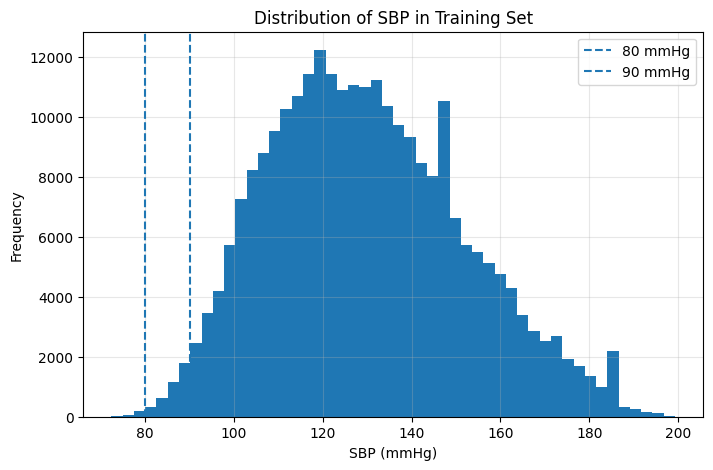

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 21.9303
MSE : 480.9400
R²  : 0.0894
MAE : 17.5982


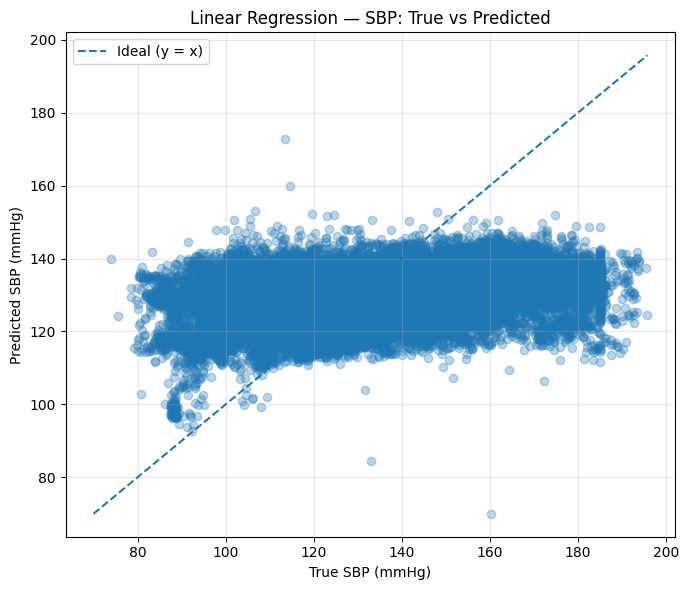

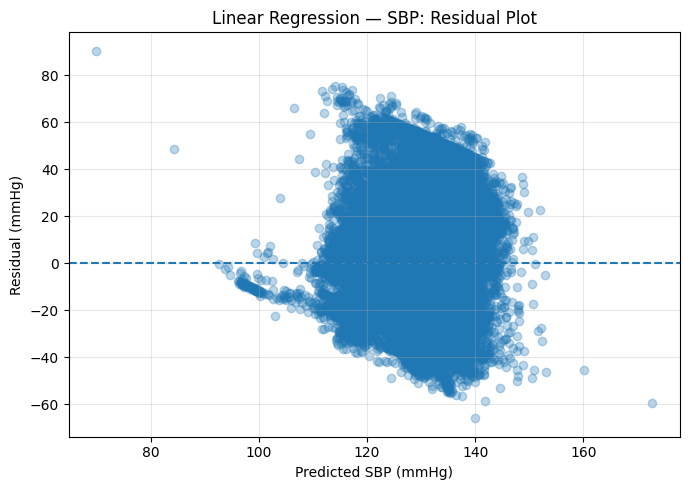

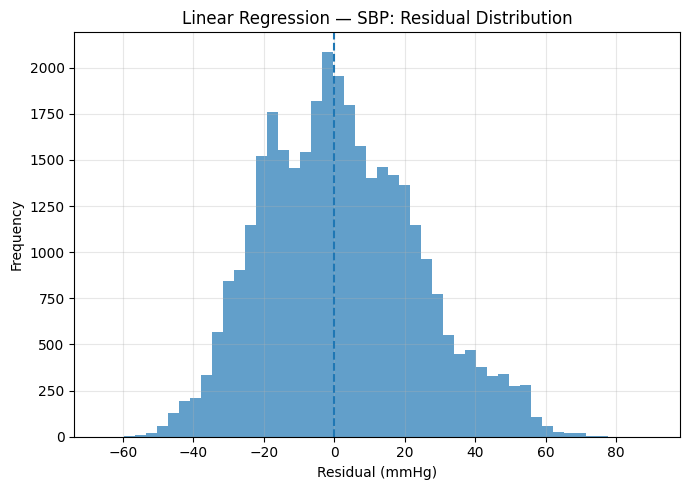

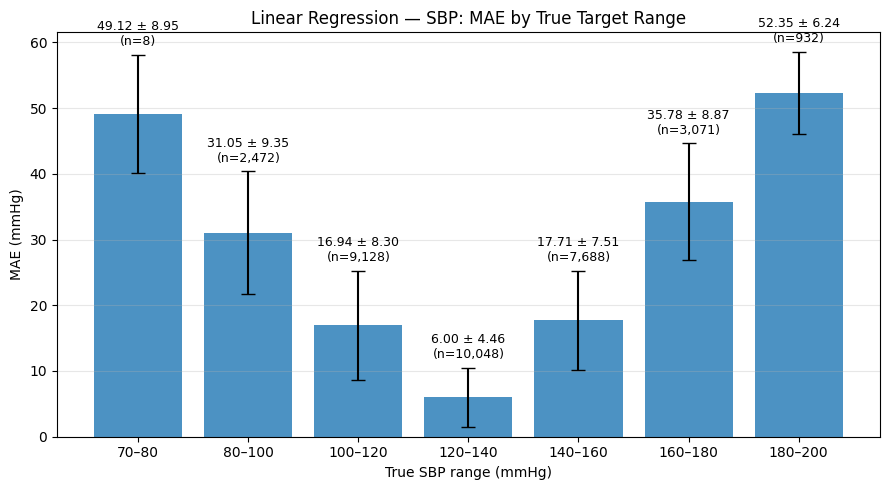

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 160.7562
MSE : 25842.5515
R²  : -59.6642
MAE : 53.7969


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


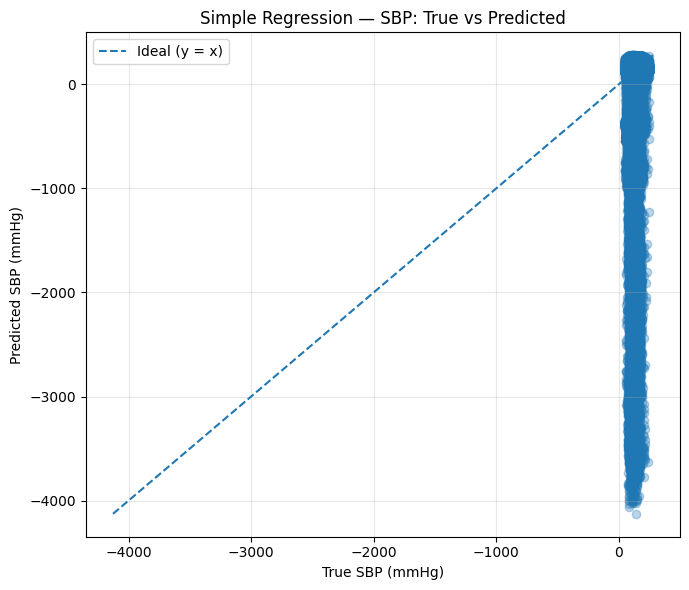

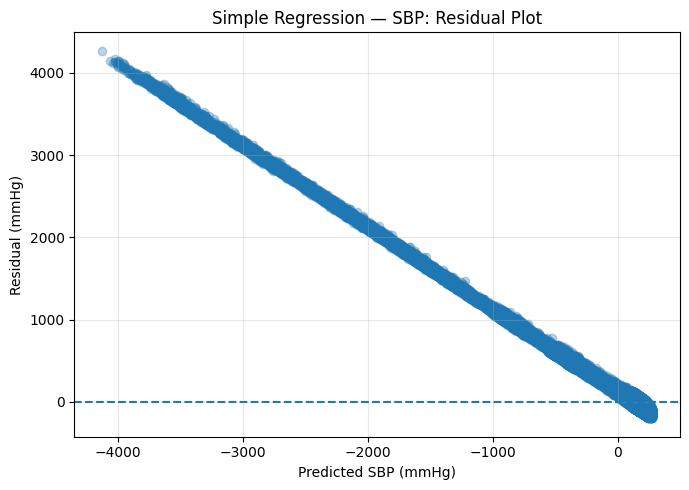

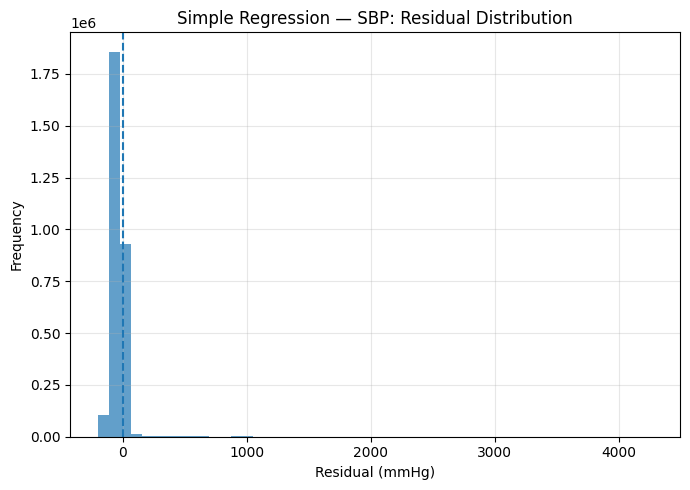

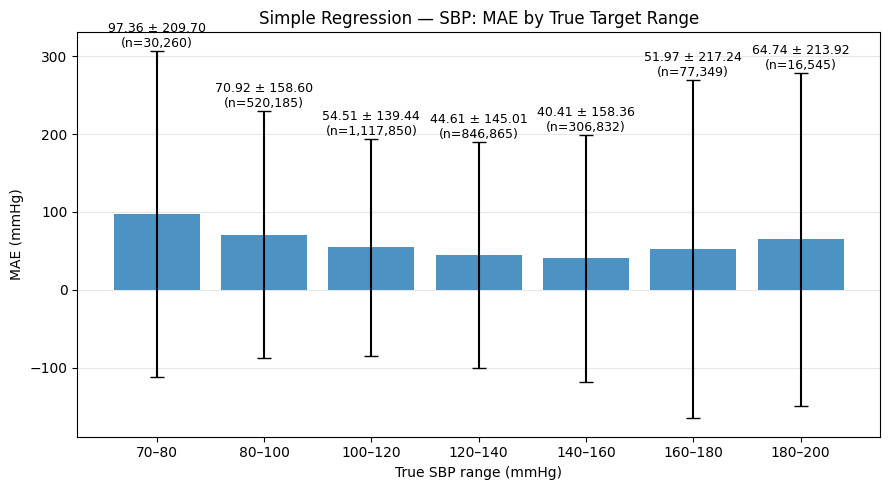

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 21.1574
MSE : 447.6375
R²  : 0.1524
MAE : 16.9304


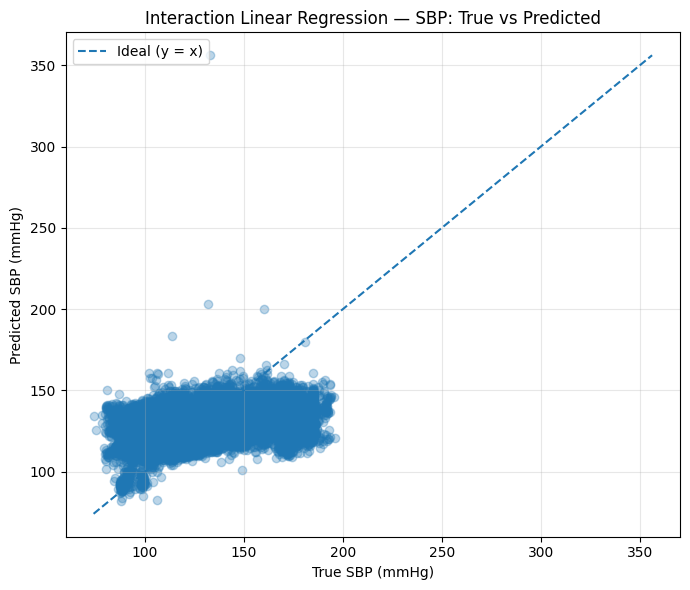

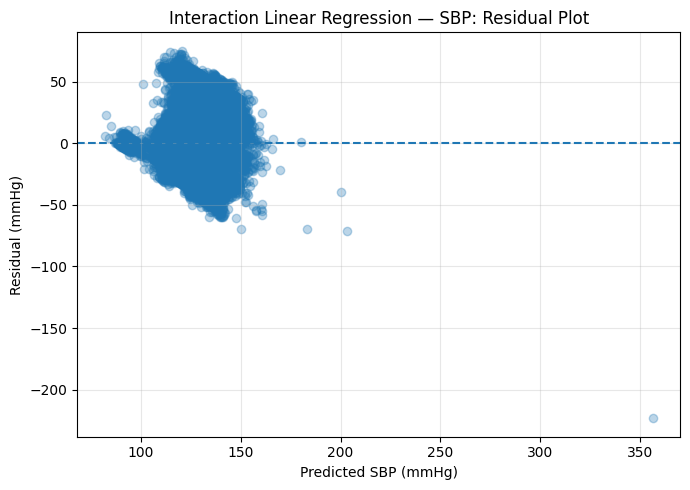

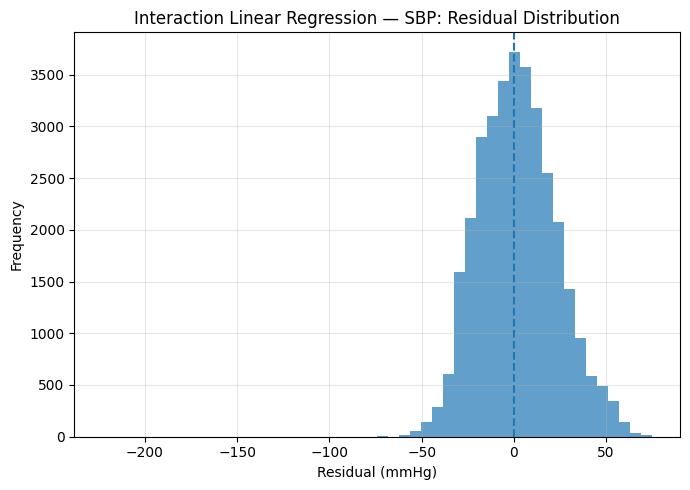

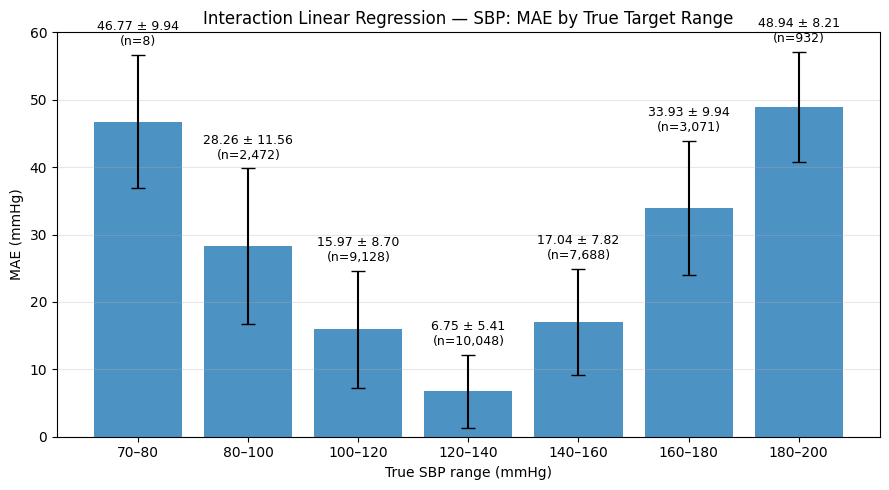

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 4323.9678
MSE : 18696697.2345
R²  : -43888.6616
MAE : 441.1037


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


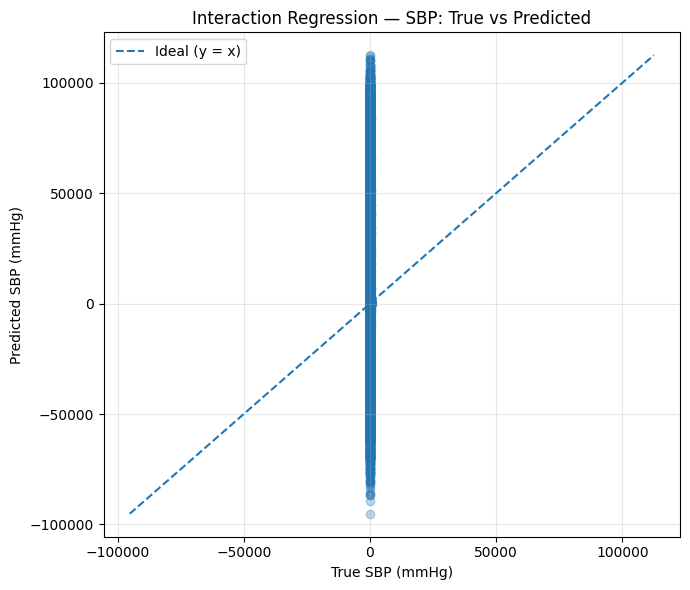

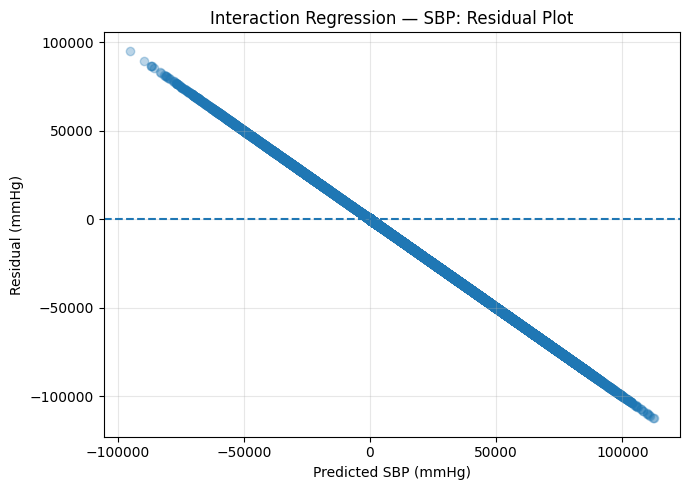

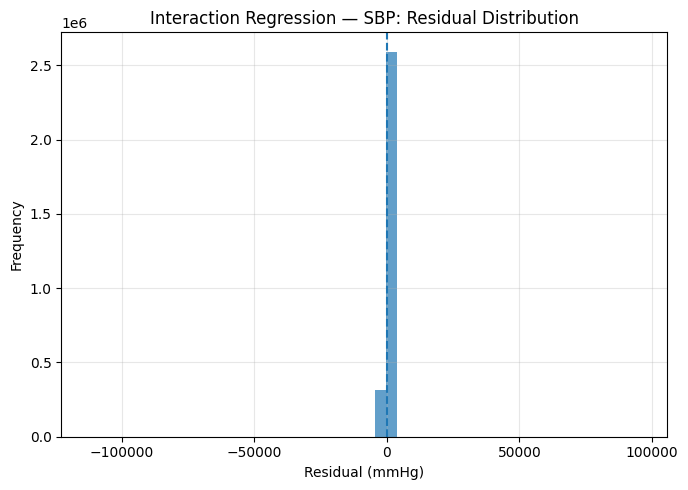

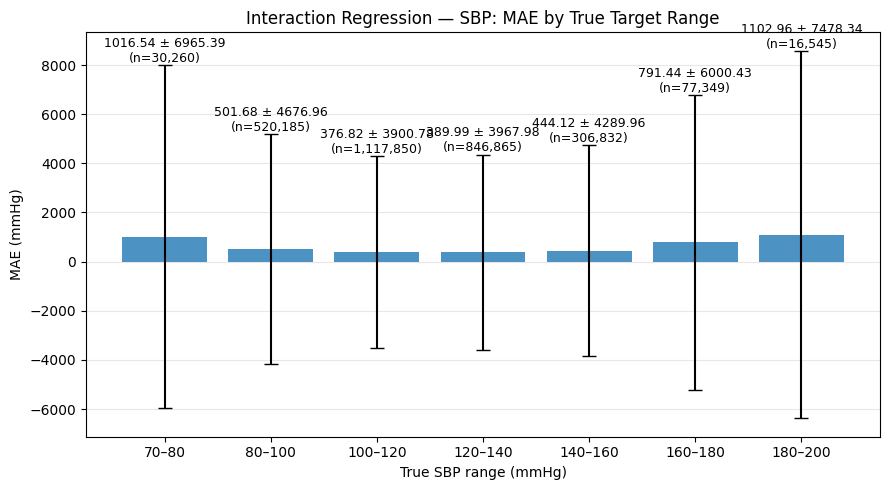

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — SBP
----------------------------------------
RMSE: 21.9569
MSE : 482.1059
R²  : 0.0872
MAE : 17.5970


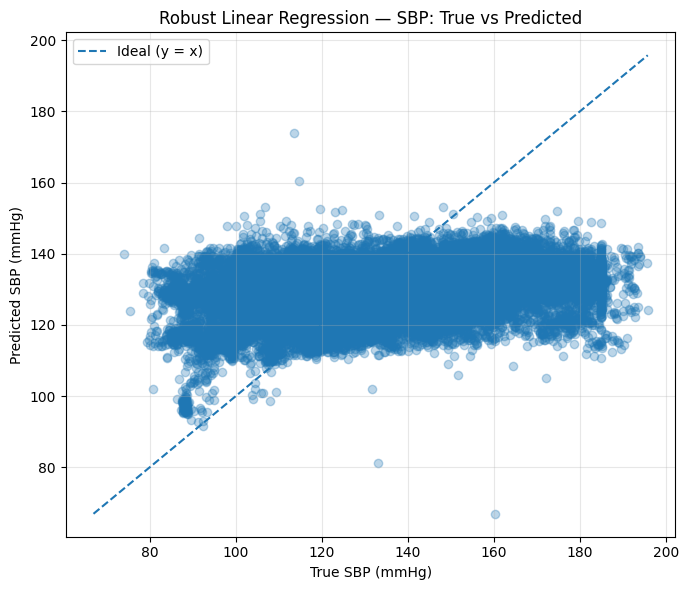

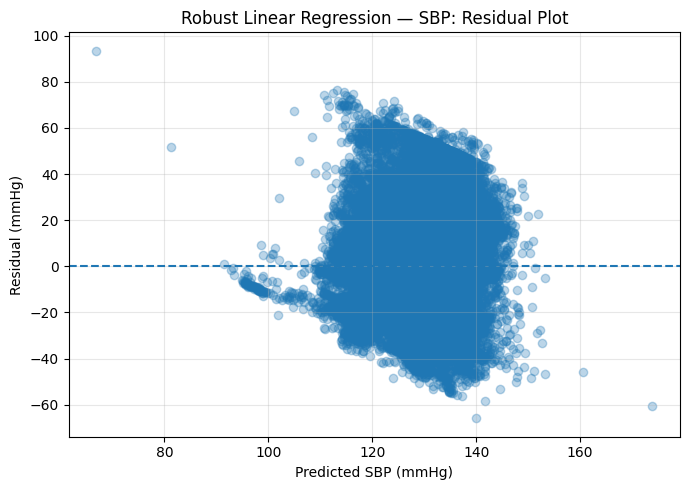

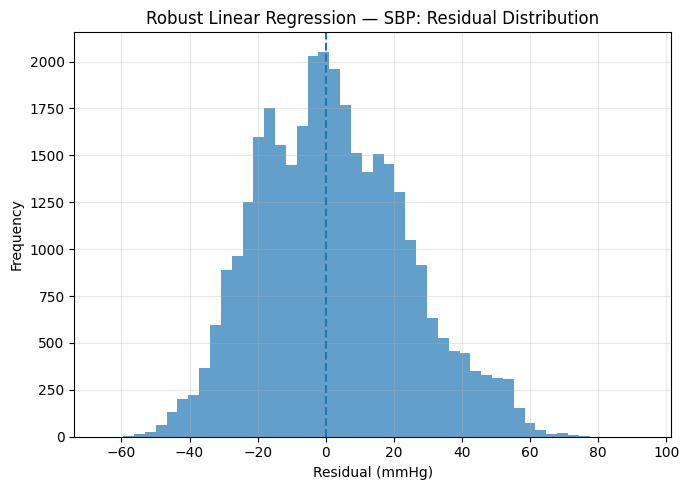

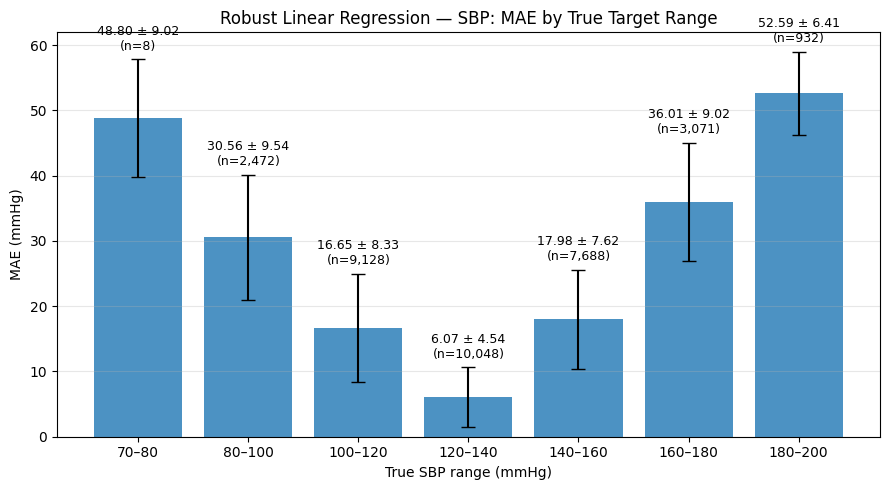

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 167.3414
MSE : 28003.1525
R²  : -64.7361
MAE : 54.9427


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


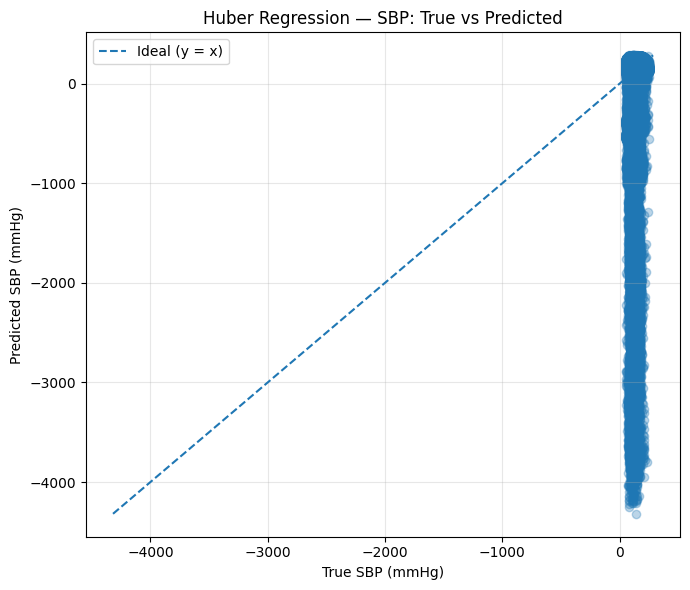

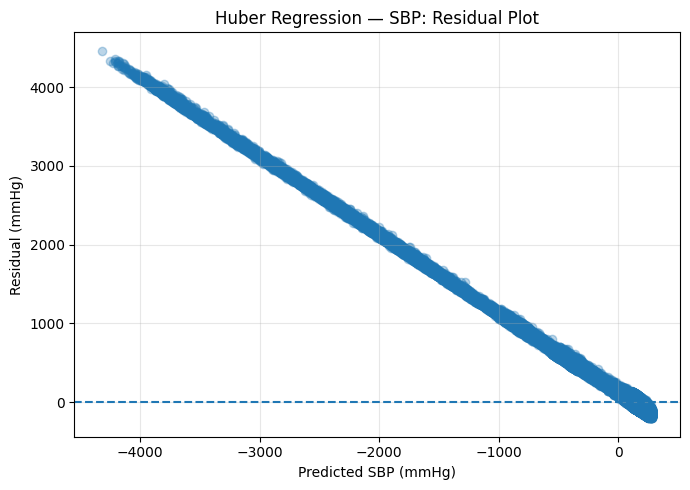

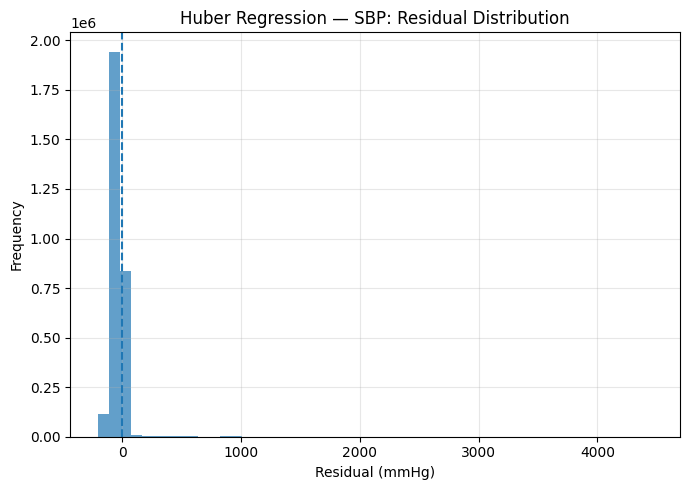

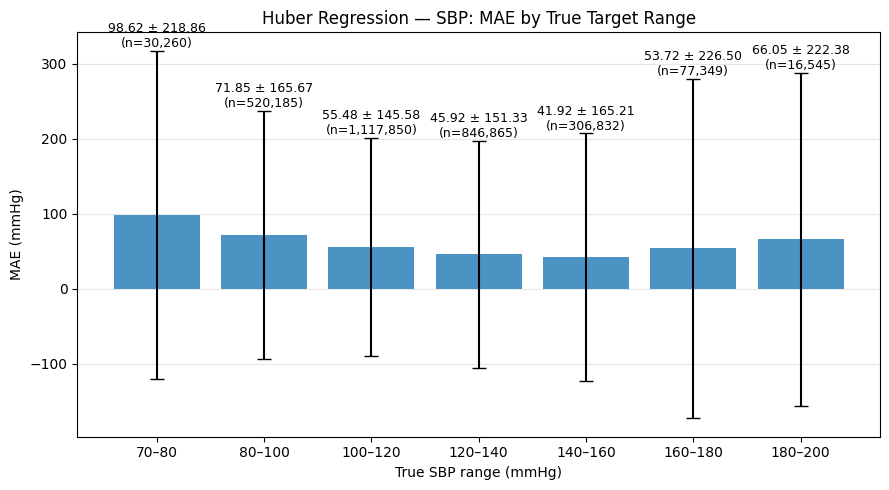

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — SBP
--------------------------------
RMSE: 20.4407
MSE : 417.8225
R²  : 0.2089
MAE : 15.8847


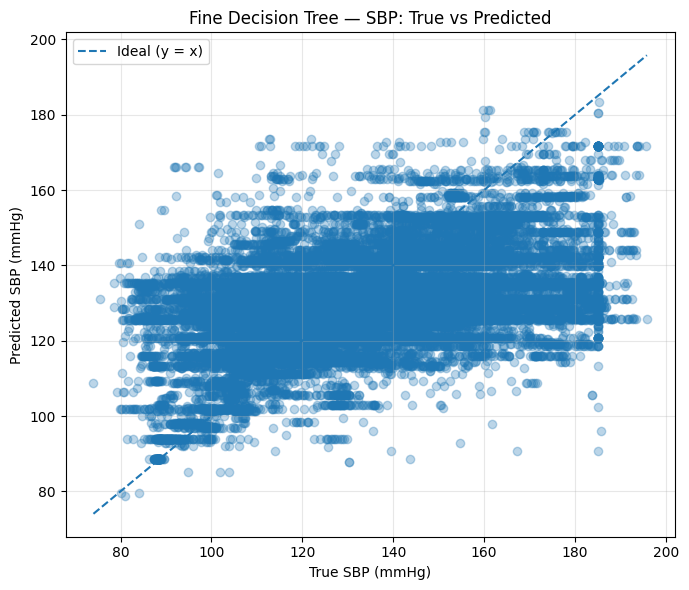

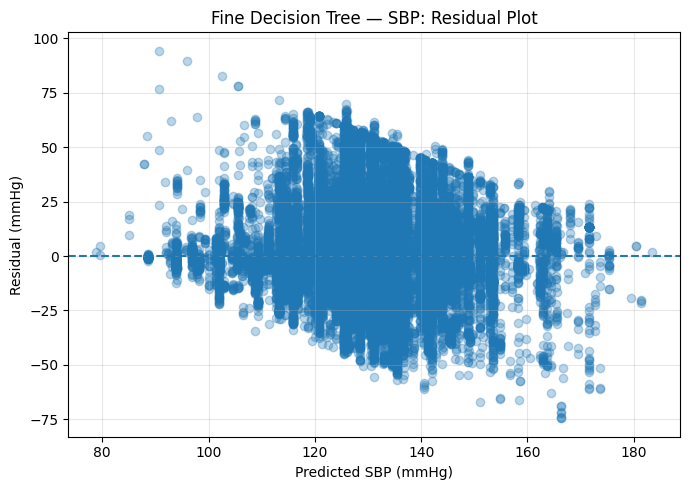

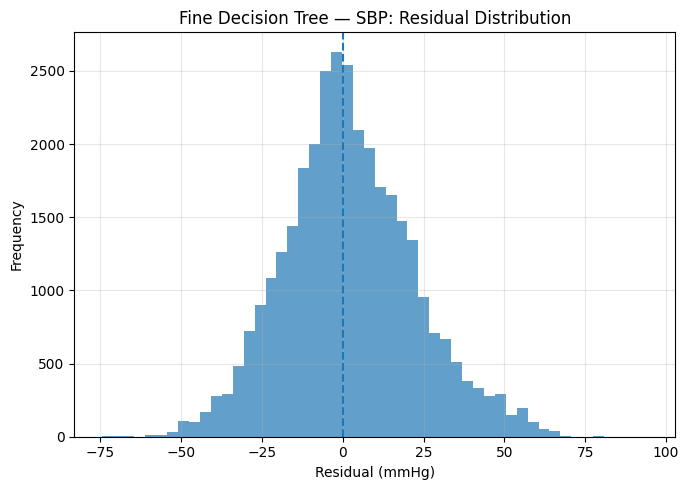

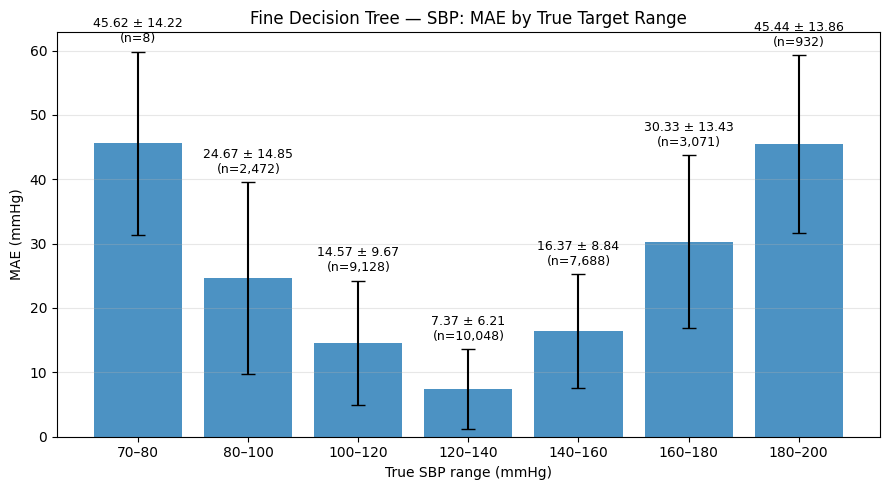

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 31.7826
MSE : 1010.1334
R²  : -1.3712
MAE : 26.3734


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


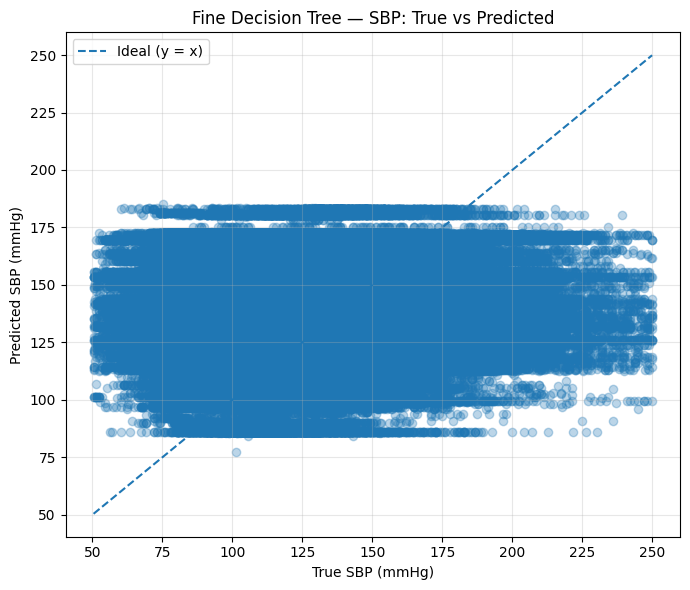

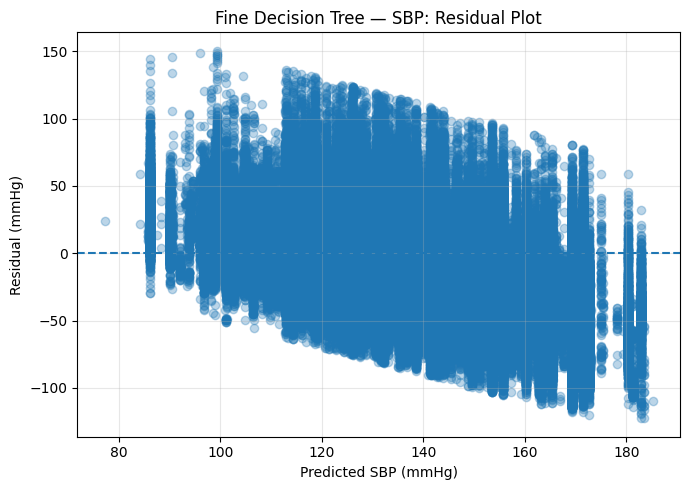

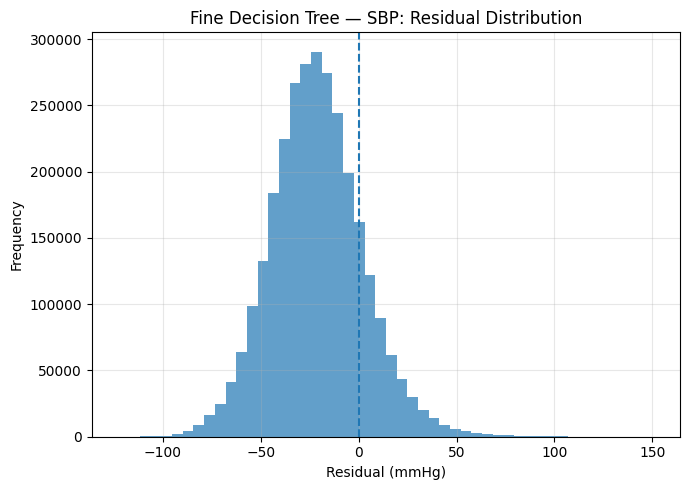

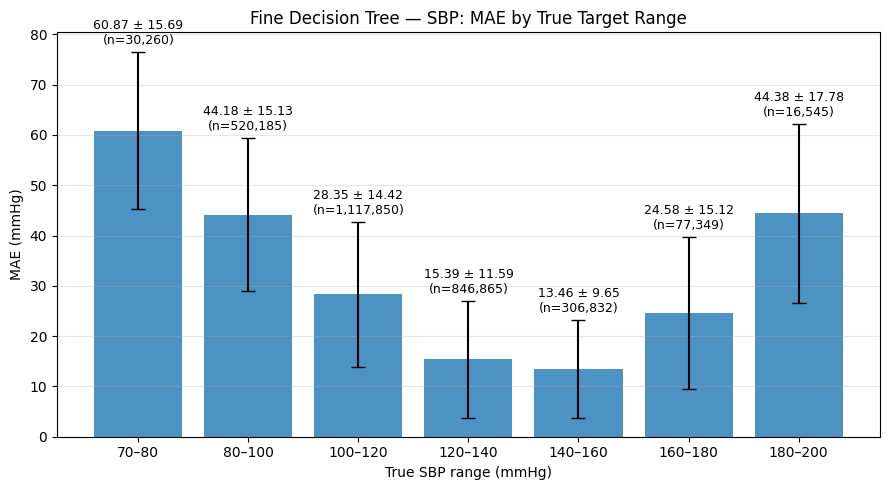

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — SBP
----------------------------
RMSE: 17.6022
MSE : 309.8387
R²  : 0.4133
MAE : 13.2811


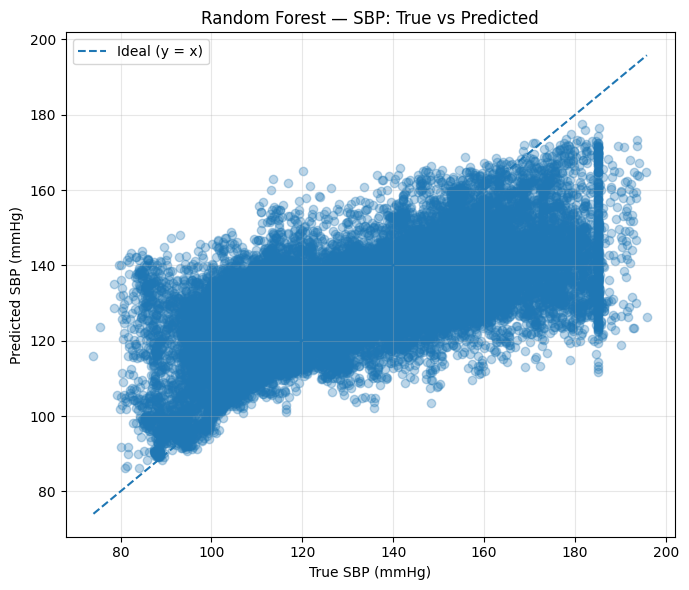

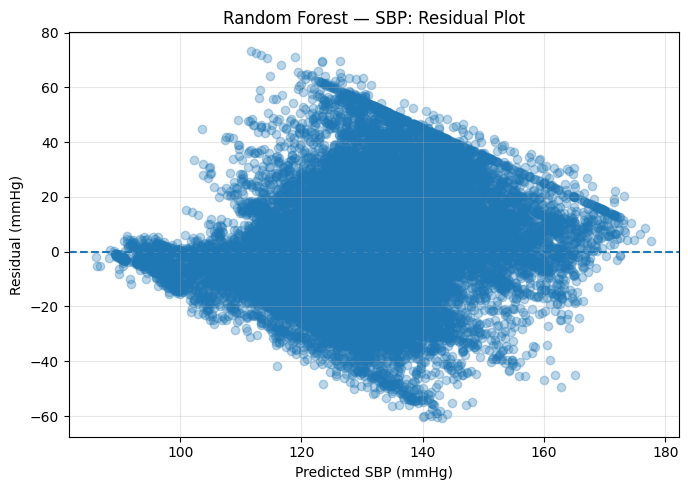

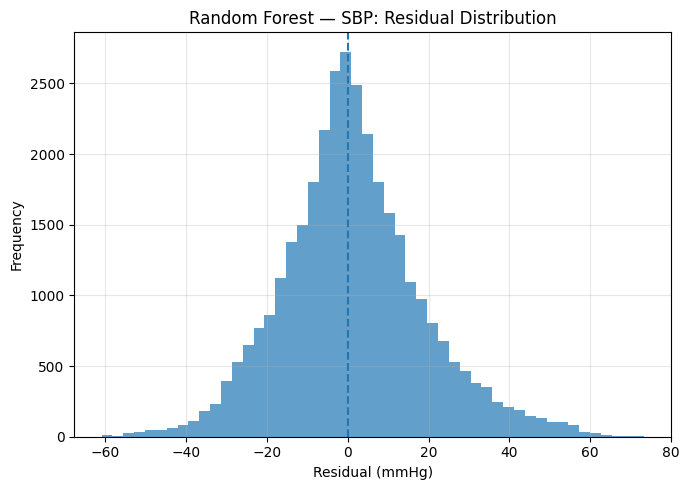

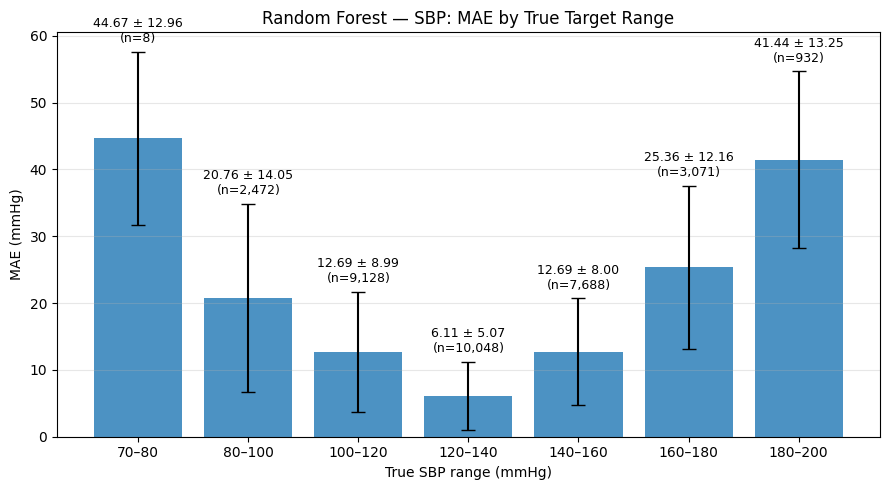

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.2030
MSE : 686.5973
R²  : -0.6118
MAE : 21.7658


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


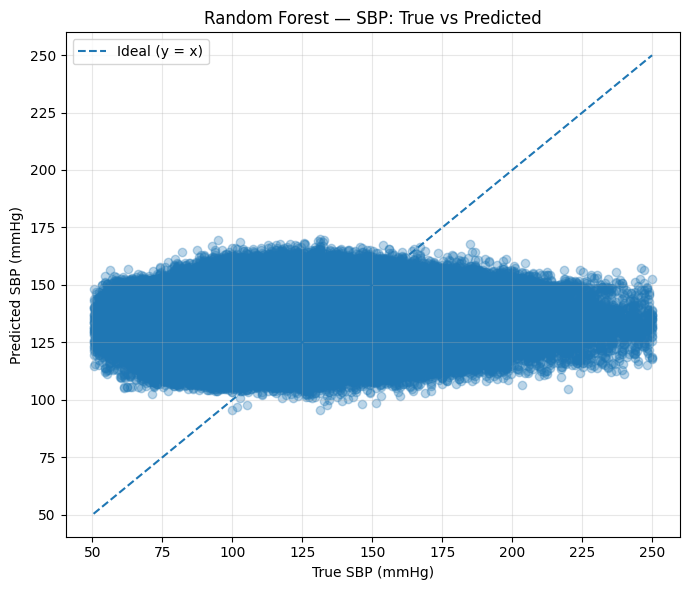

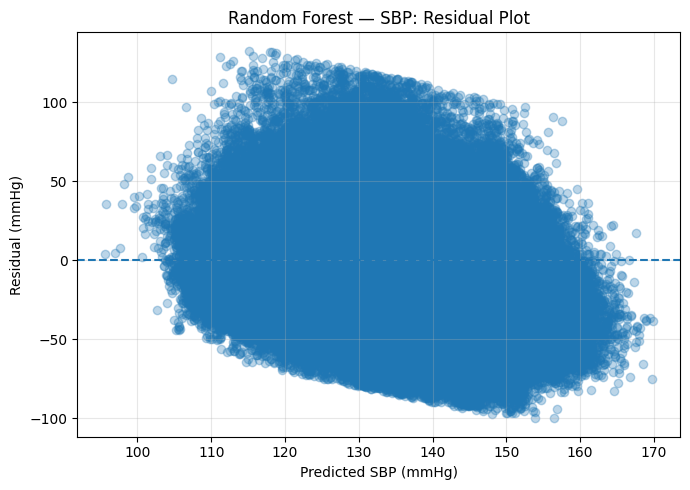

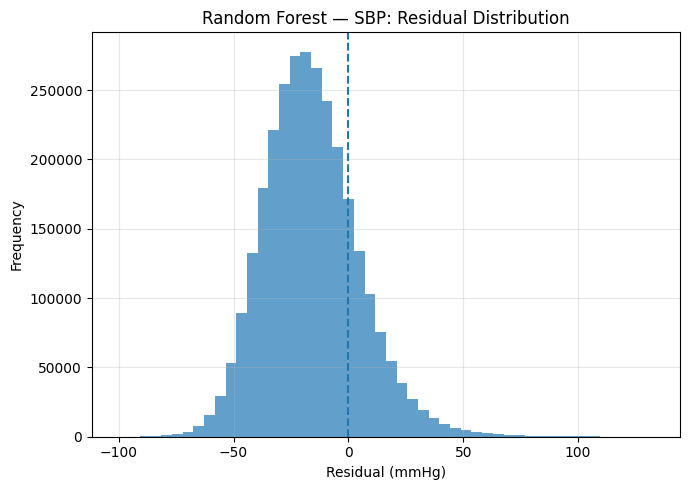

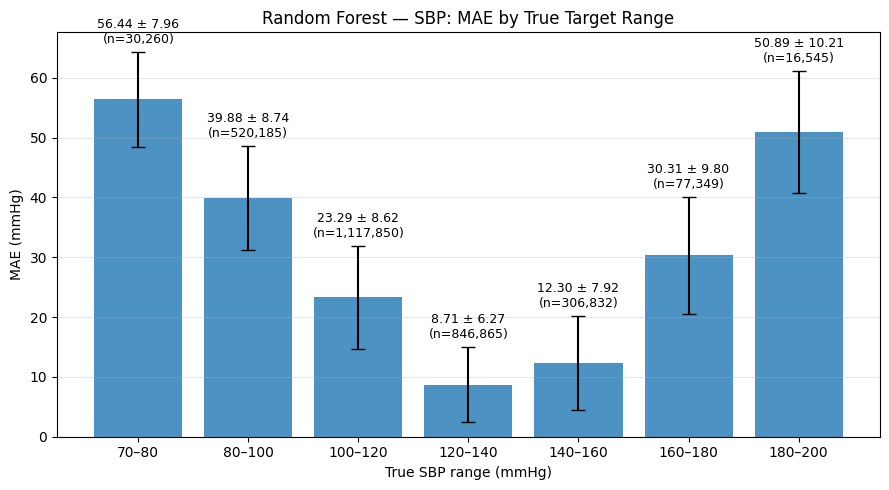

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — SBP
--------------------------------------
RMSE: 17.3782
MSE : 302.0035
R²  : 0.4282
MAE : 12.8755


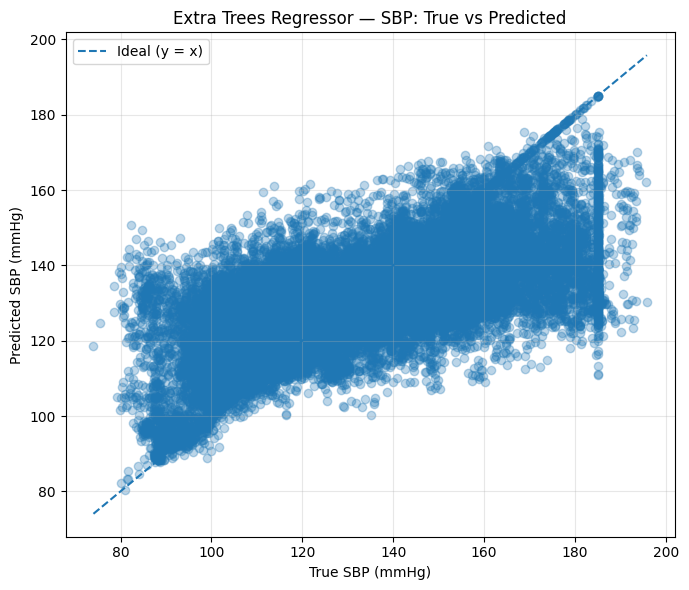

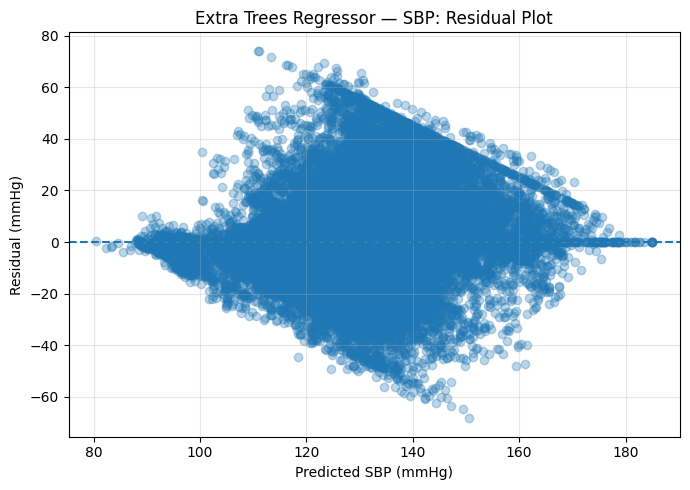

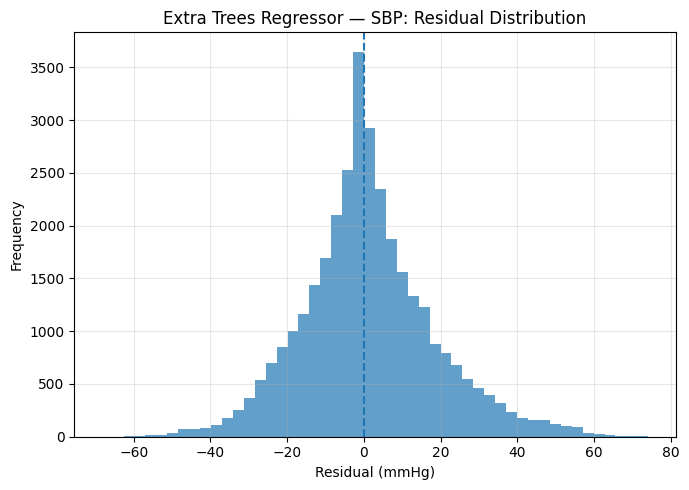

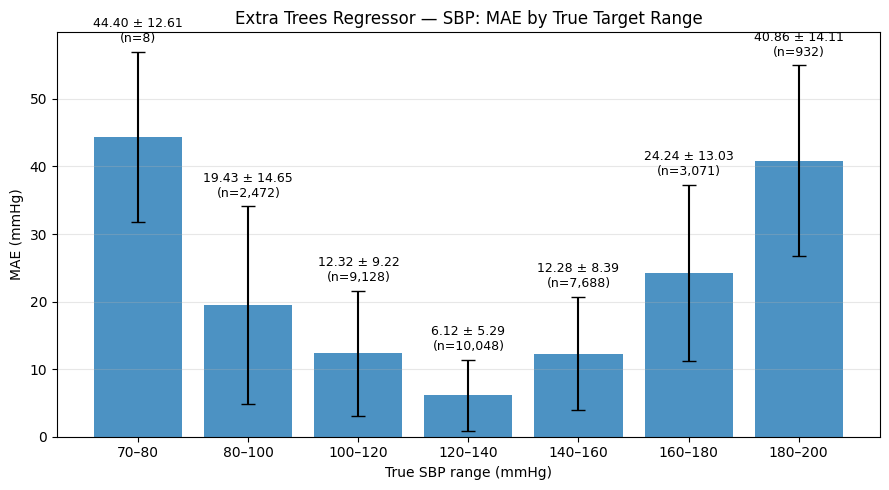

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.9956
MSE : 728.7631
R²  : -0.7107
MAE : 22.5199


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


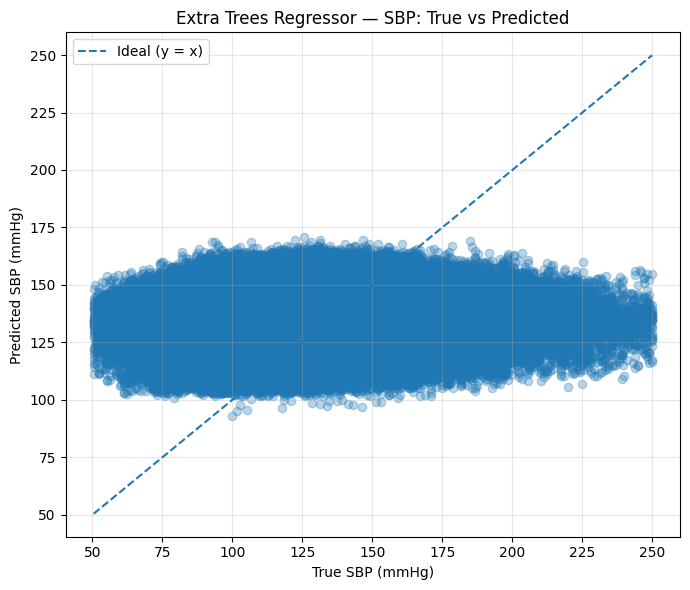

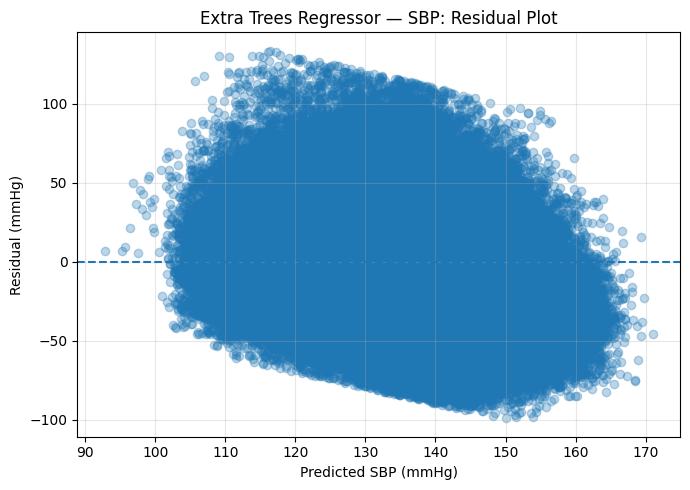

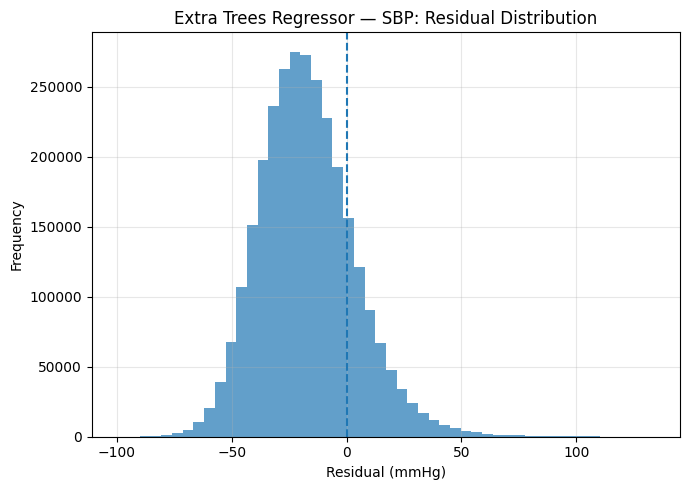

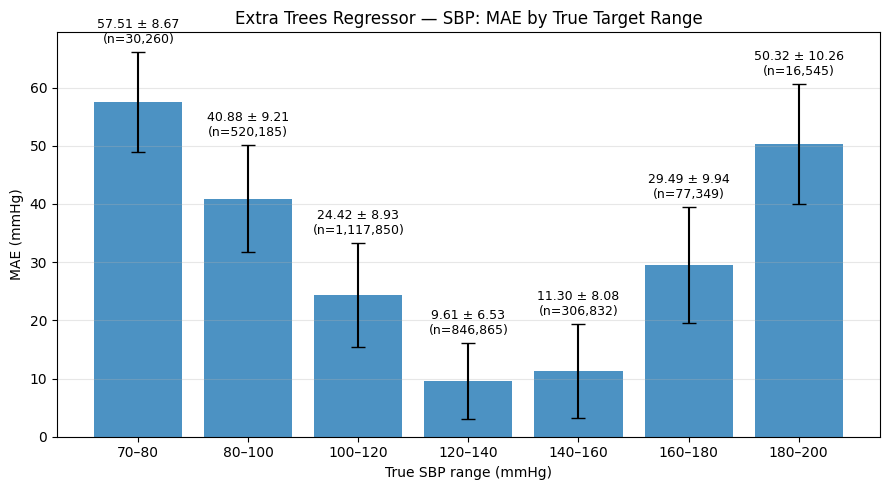

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — SBP
---------------------
RMSE: 18.6719
MSE : 348.6392
R²  : 0.3399
MAE : 14.4860


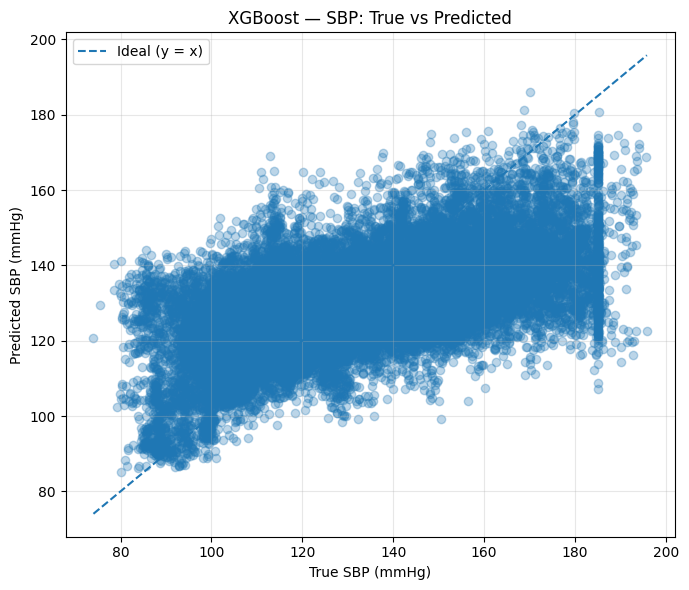

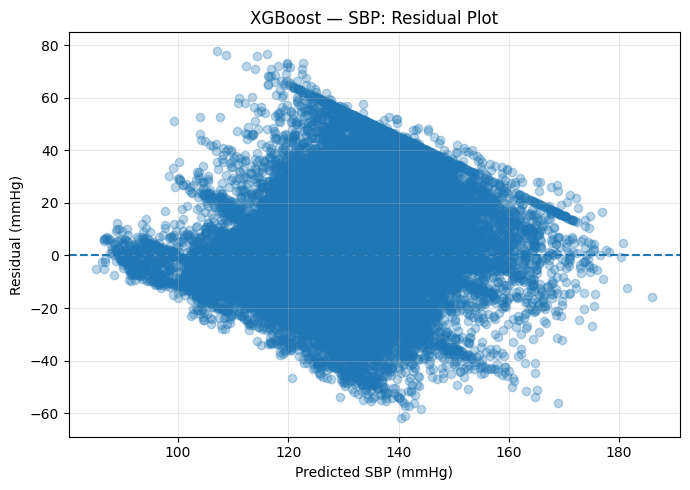

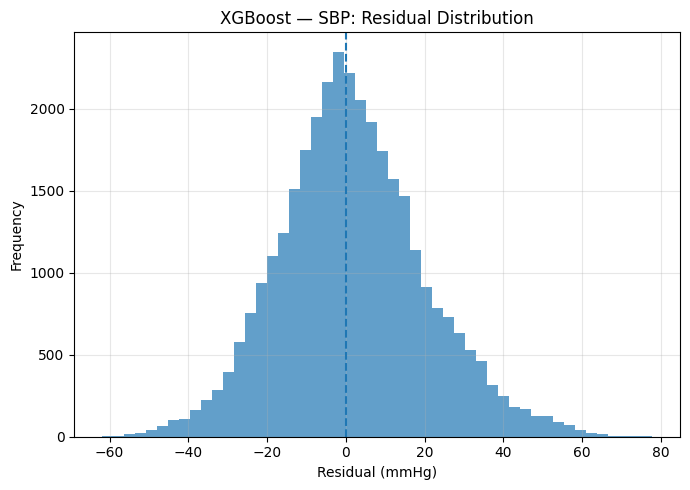

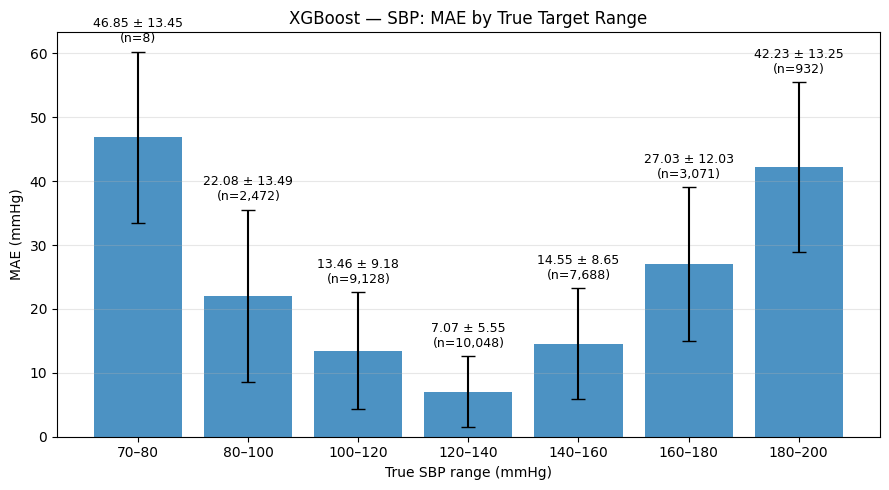

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 31.4523
MSE : 989.2453
R²  : -1.3222
MAE : 26.4064


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


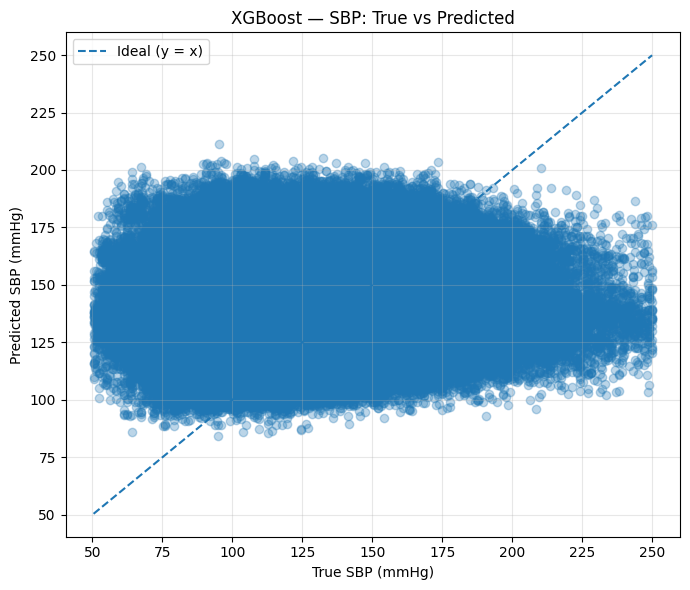

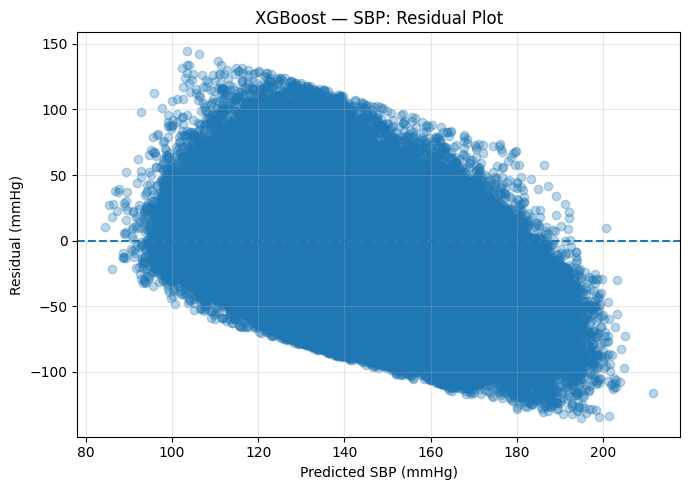

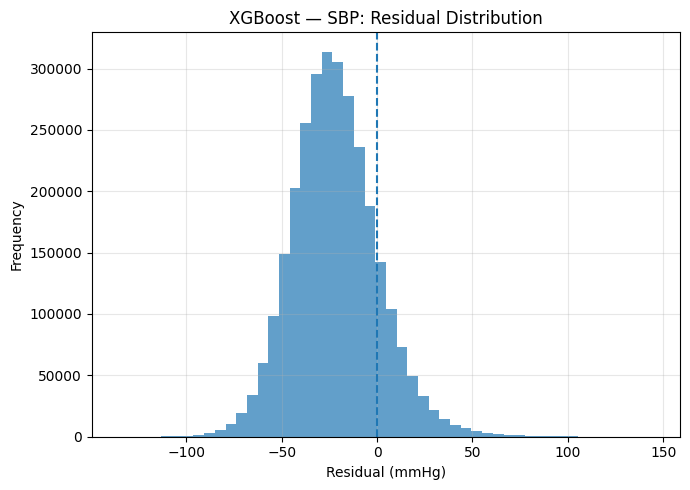

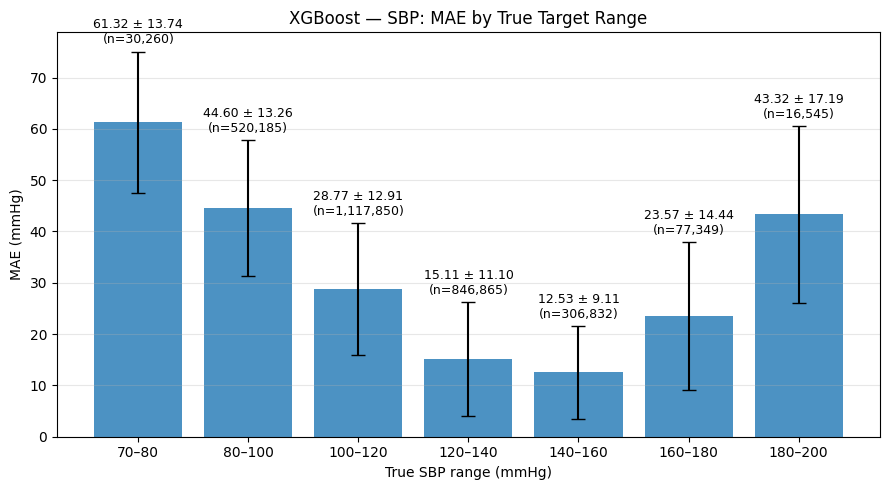

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   1.1s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   1.1s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   1.4s


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   1.4s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   2.3s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.4s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   2.9s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time=   2.7s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   1.5s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time=   2.0s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   5.3s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   1.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estim

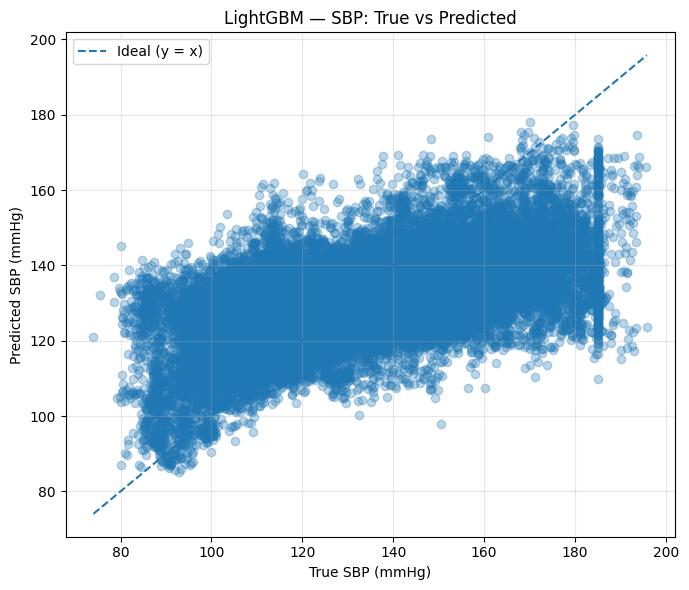

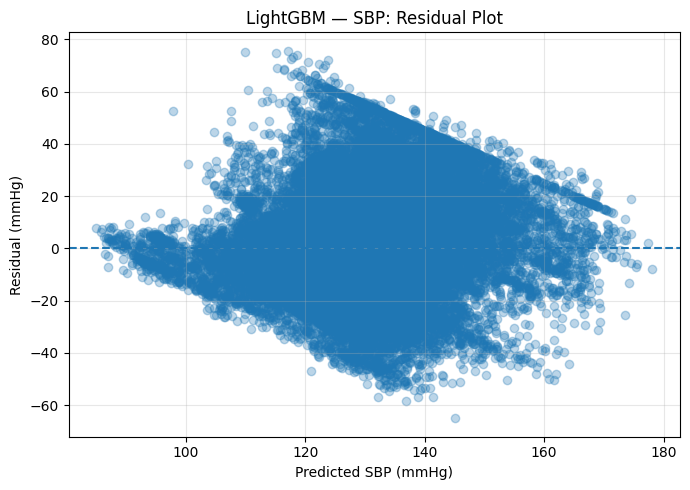

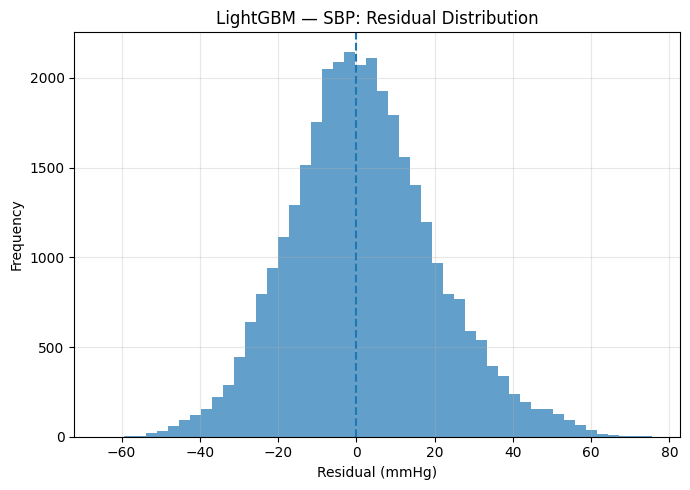

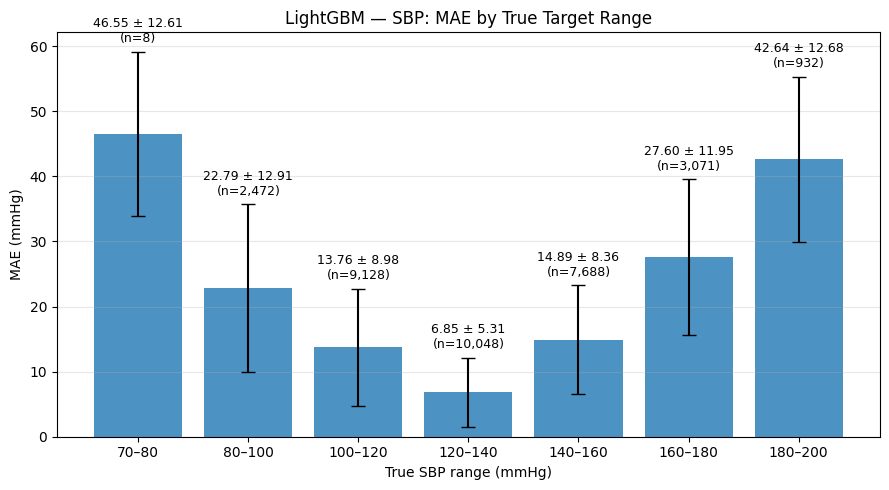

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 29.8493
MSE : 890.9836
R²  : -1.0915
MAE : 24.9216


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


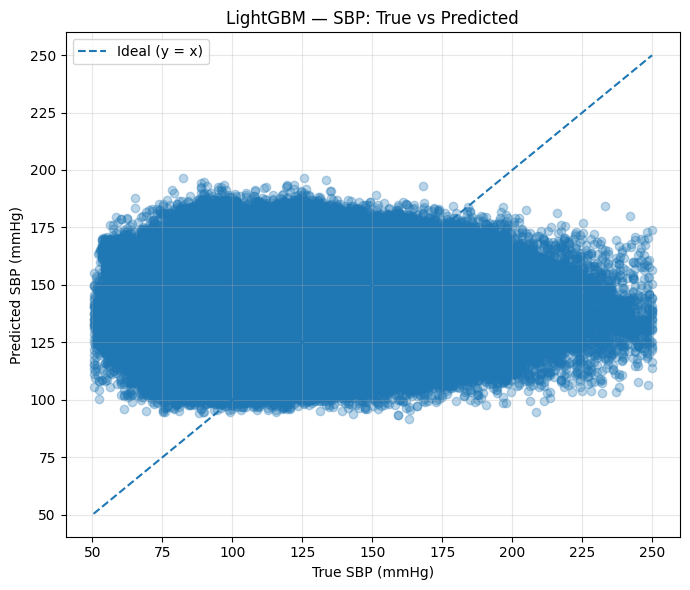

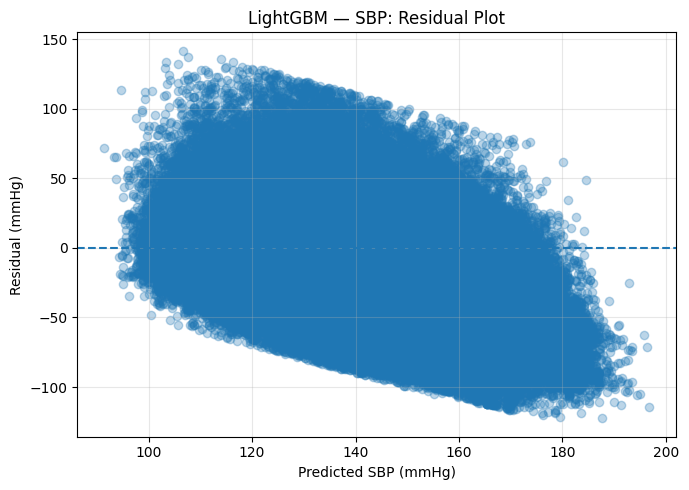

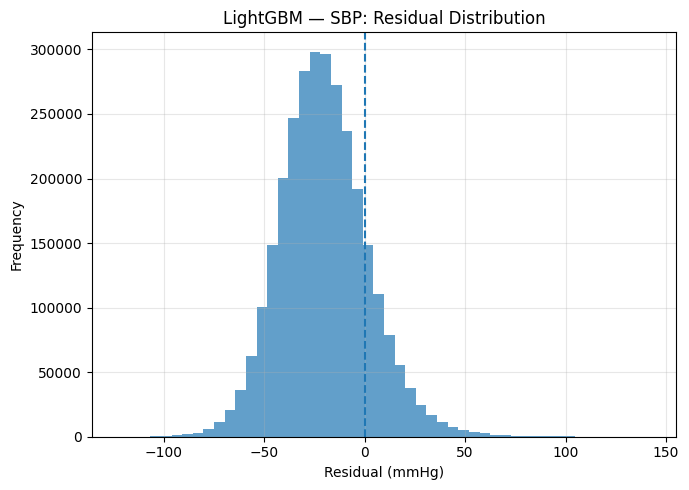

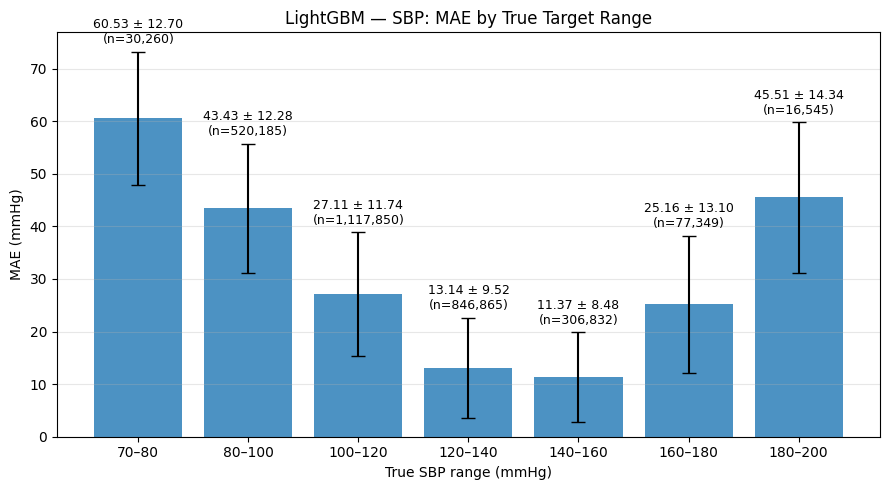

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

Best parameters:
{'kernel': 1**2 * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — SBP
--------------------------------
RMSE: 20.3673
MSE : 414.8257
R²  : 0.2146
MAE : 16.1025


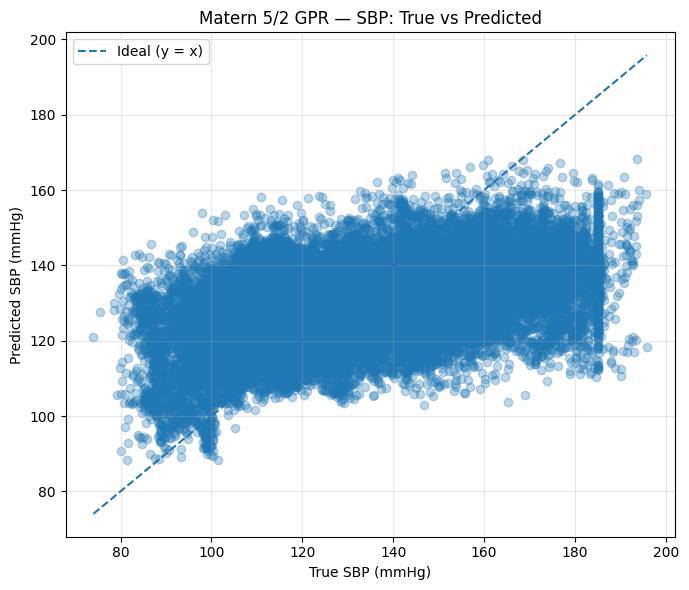

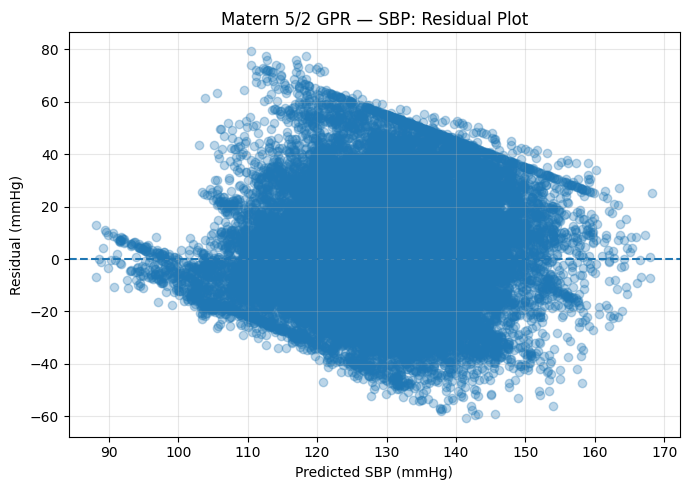

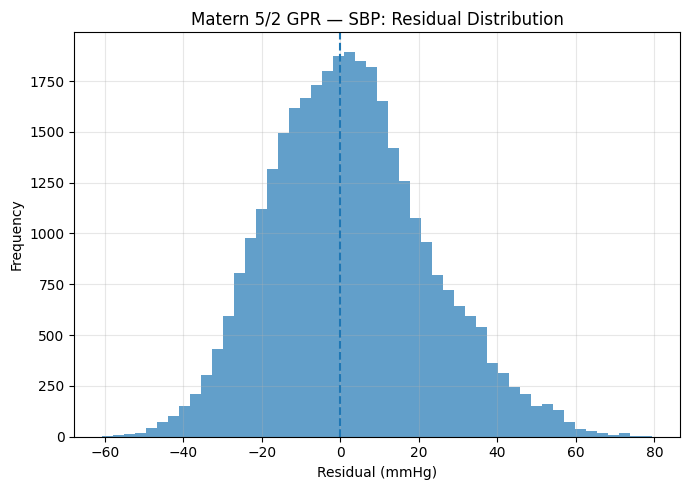

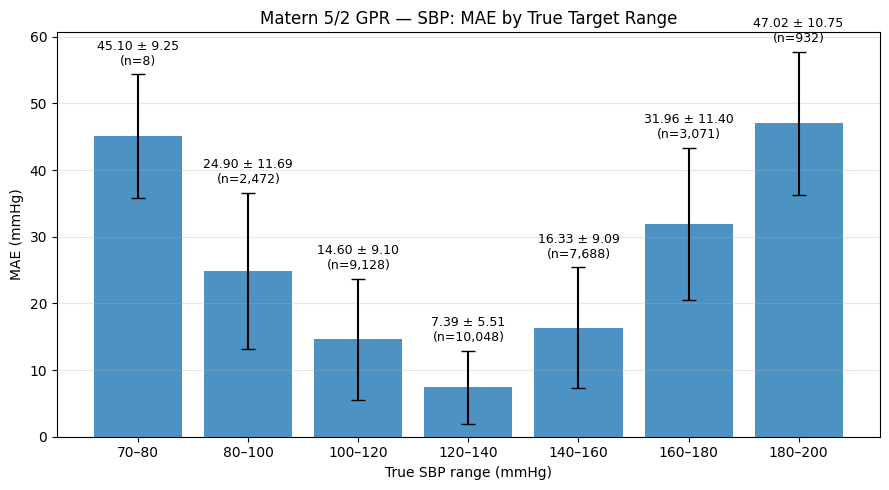

In [27]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 24.7406
MSE : 612.0954
R²  : -0.4369
MAE : 20.3112


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


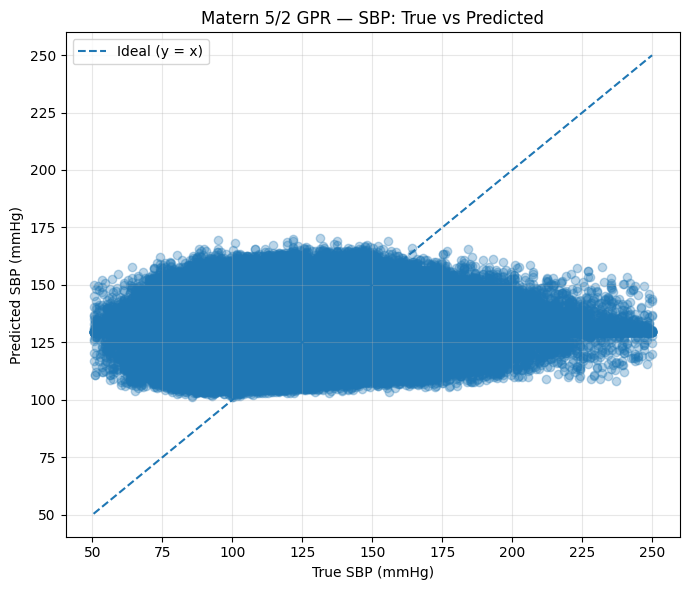

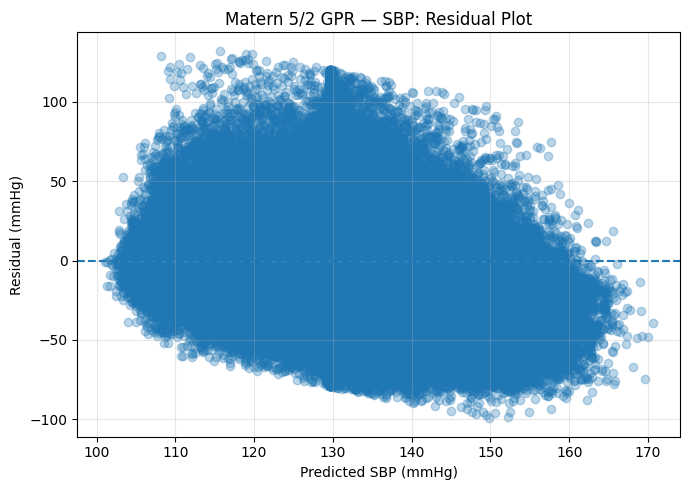

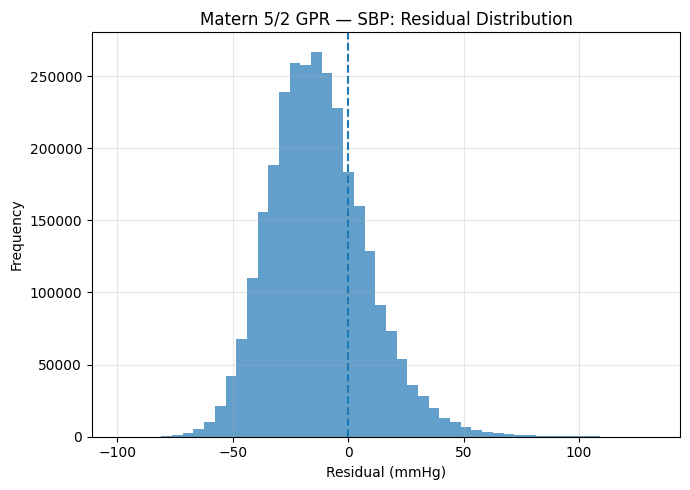

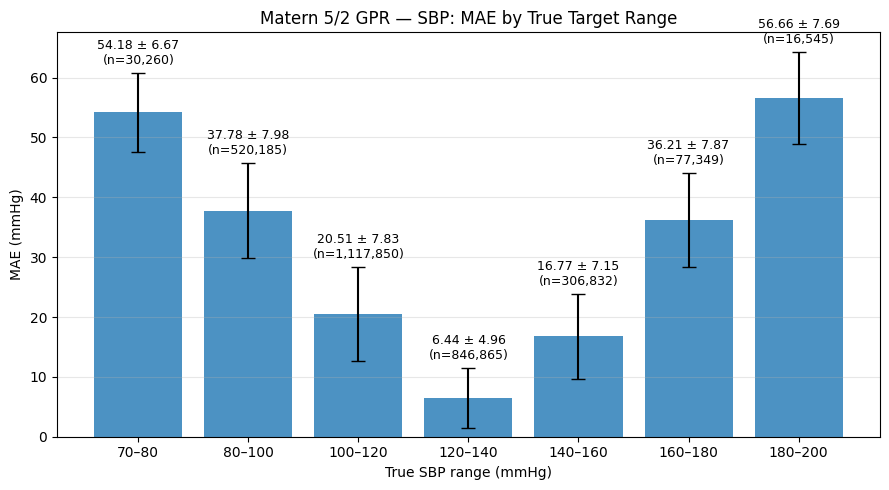

In [28]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a bette


Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=2) + WhiteKernel(noise_level=1)}

Best CV RMSE: 19.42254020297381

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=2) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 33,347 samples...
RMSE: 20.4152
MSE : 416.7801
R²  : 0.2109
MAE : 16.0243


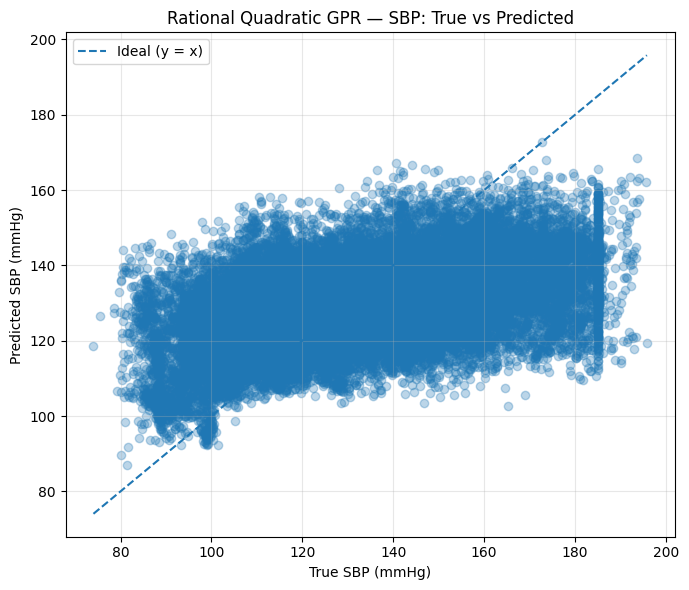

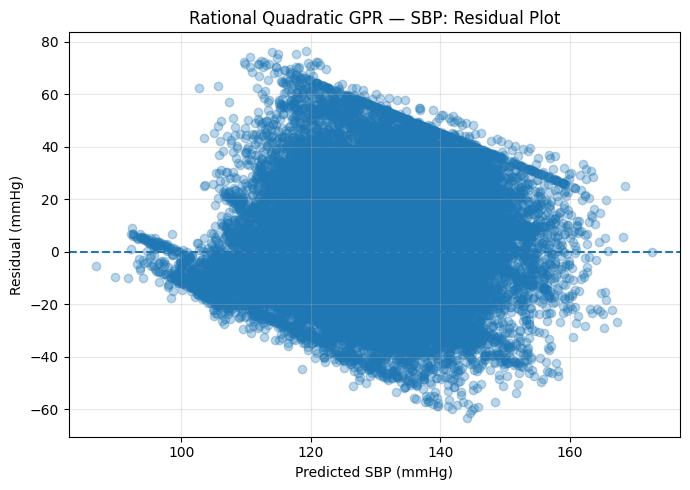

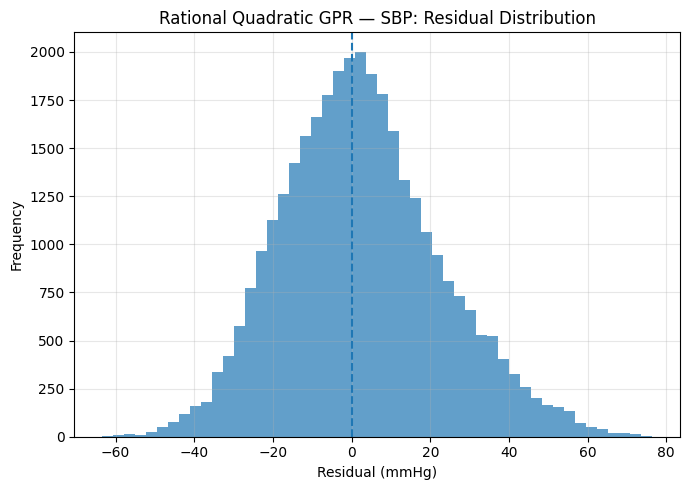

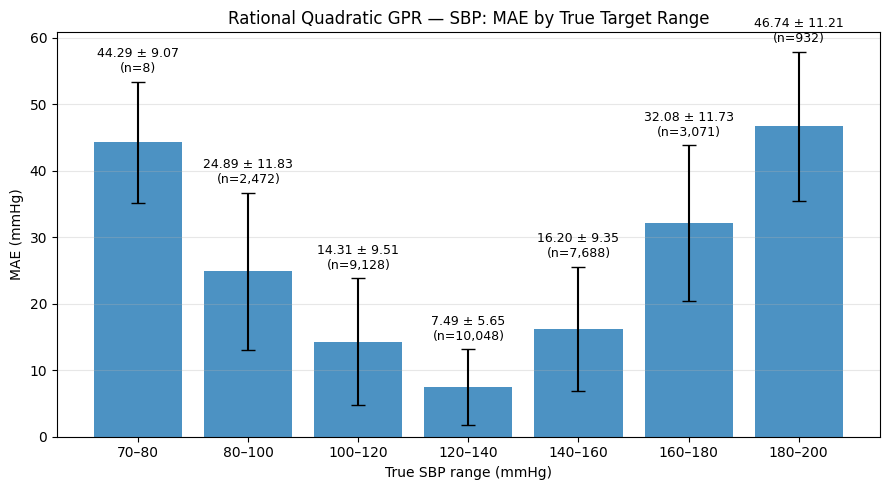

In [29]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 24.6732
MSE : 608.7672
R²  : -0.4291
MAE : 20.2292


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


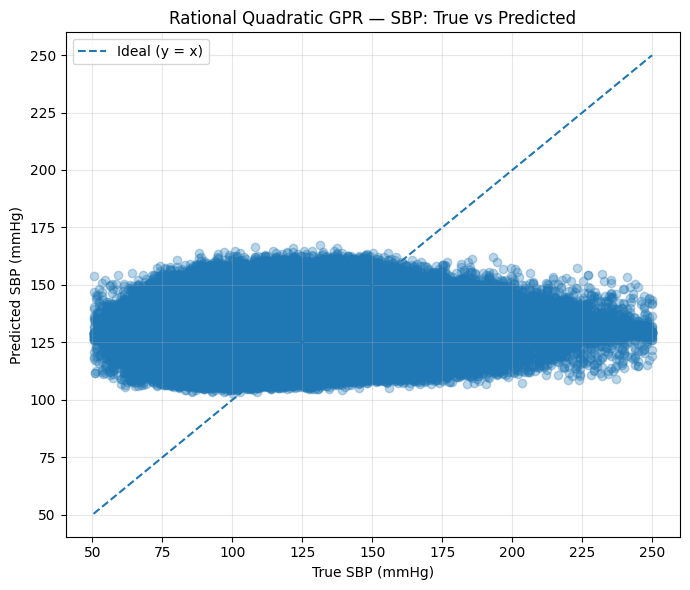

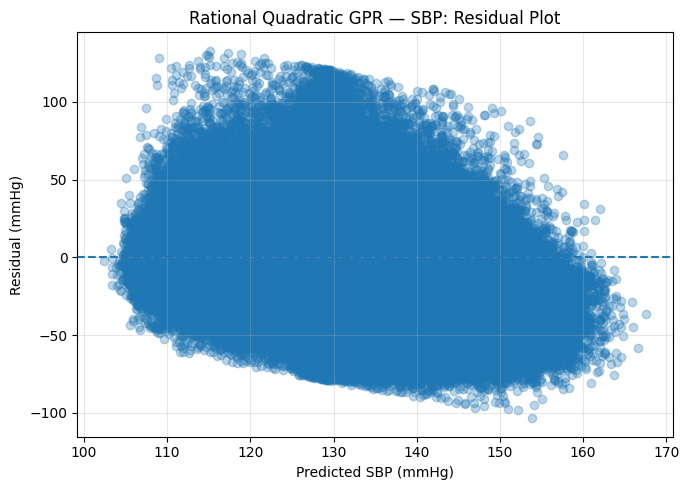

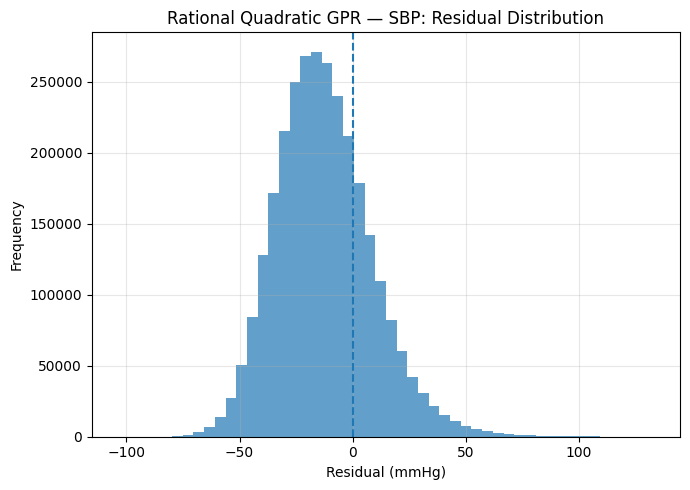

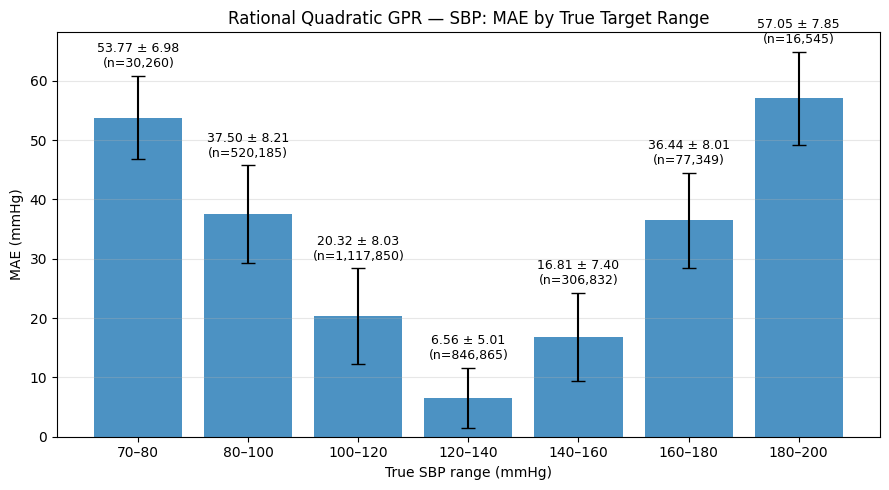

In [30]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.01, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

Best CV RMSE: 20.365250586168322

Best ANN / MLP model:
MLPRegressor(alpha=0.01, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(128, 64), max_iter=300, n_iter_no_change=20,
             random_state=42)

Starting batched prediction on 33,347 samples...
Processed 10,000 / 33,347
Processed 20,000 / 33,347
Processed 30,000 / 33,347
Processed 33,347 / 33,347

ANN / MLP Regressor — SBP
------------------------------------
RMSE: 22.9247
MSE : 525.5411
R²  : 0.0049
MAE : 16.5311


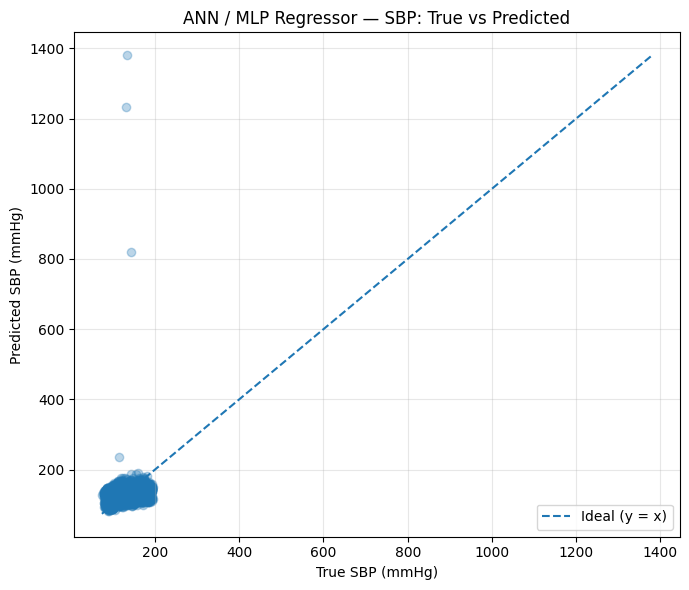

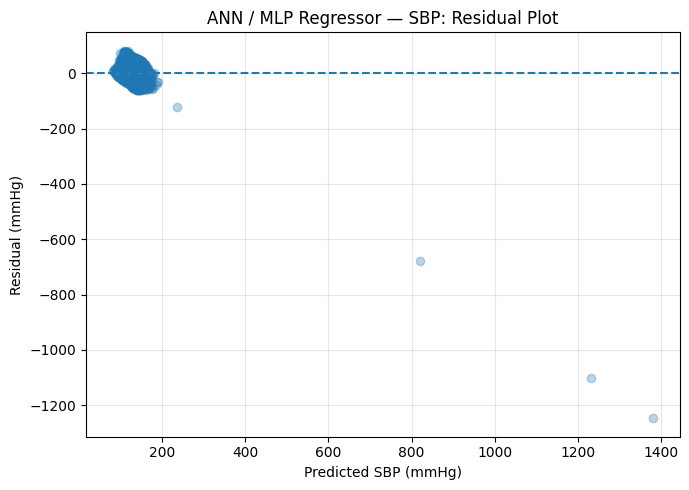

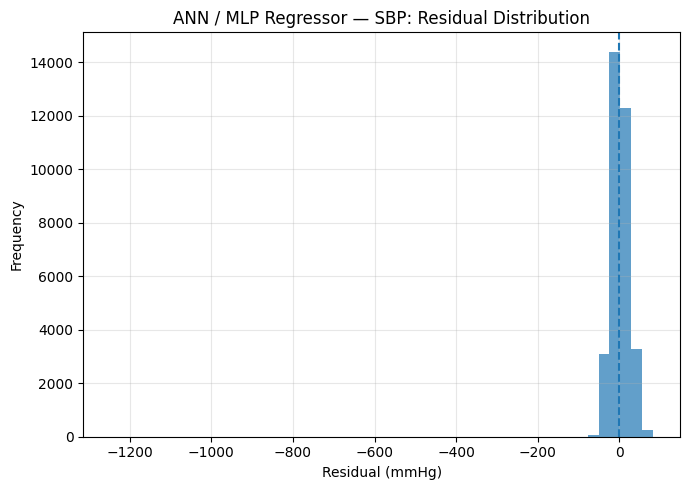

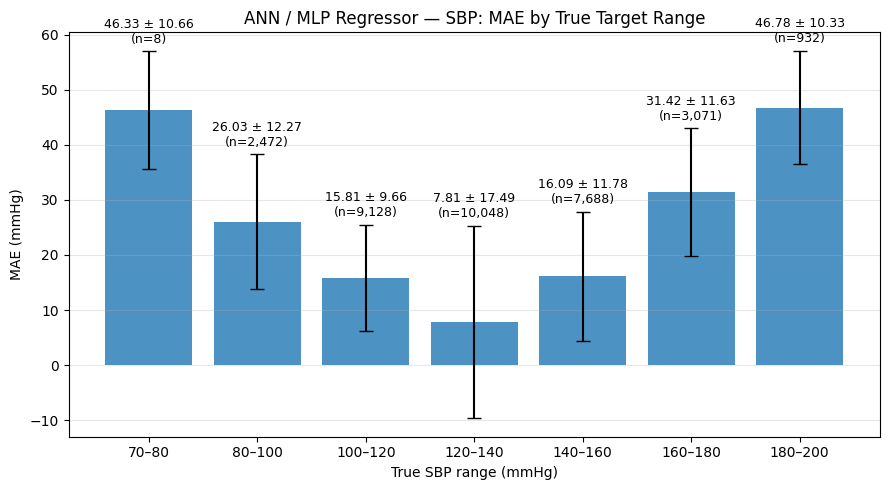

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 564.6645
MSE : 318845.9883
R²  : -747.4767
MAE : 116.0439


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


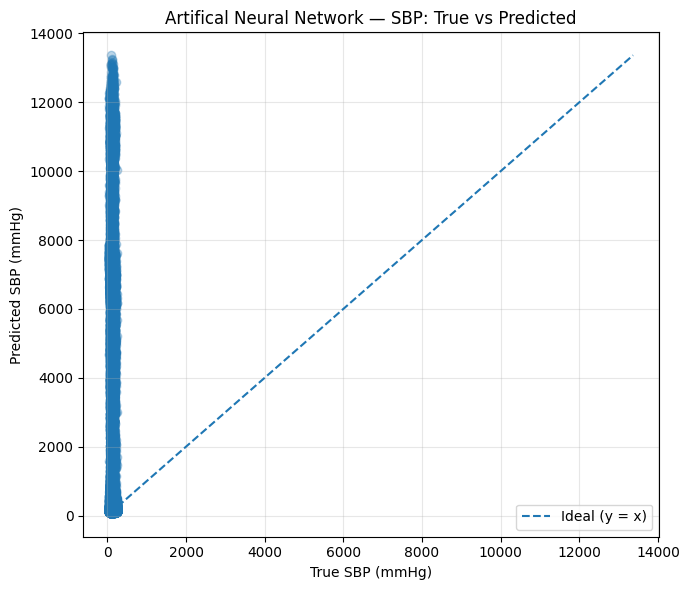

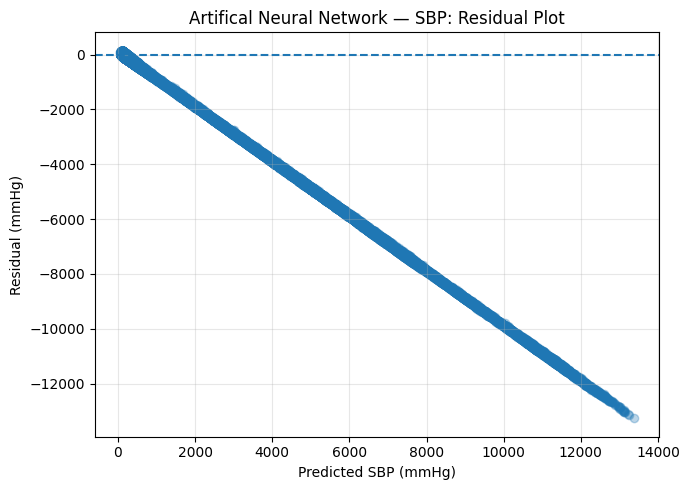

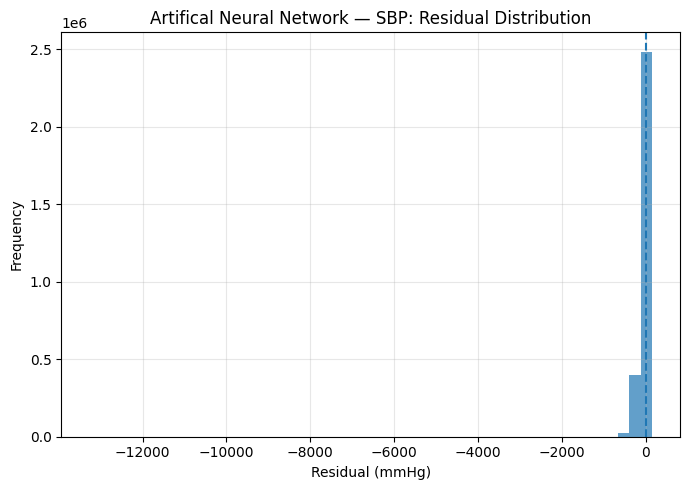

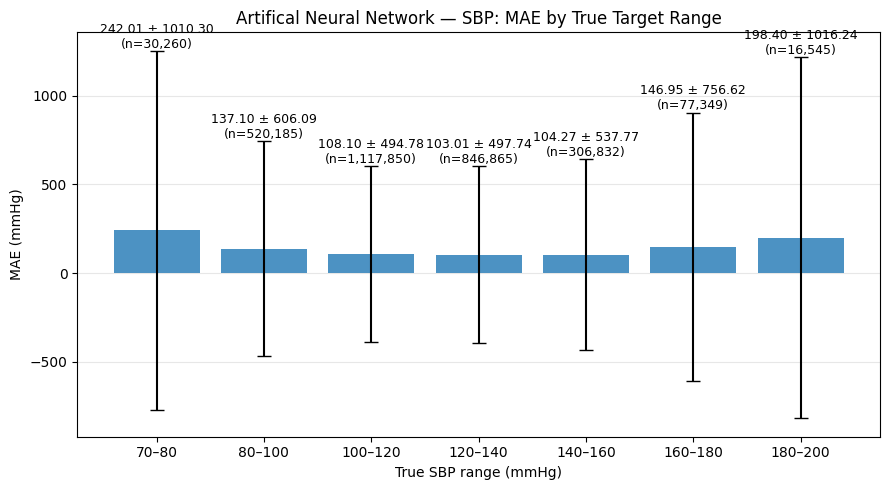

In [32]:
y_pred_vitaldb = predict_gpr_in_batches(
    ann_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)